# 08 — Diagnostic Analyses (Hybrid Value & Tiered Ensemble)

**Pipeline stage 8 of 7** (appended). Implements the revised-contribution diagnostics:
decomposed uncertainty, operational triage, tiered ensemble, coverage calibration,
and uncertainty cross-validation.

> **Read before running.** Two findings from auditing the pipeline change what is
> defensible here:
> 1. `entropy` as saved by notebook 04 is **exactly** the binary entropy of `y_mean`
>    (a deterministic transform of the point estimate), so it is *not* an independent
>    uncertainty signal. Section B audits this; Section C shows the correct
>    law-of-total-variance decomposition, which requires the notebook-04 patch.
> 2. The four simple baselines, the LSTM stream, and the MC ensemble matrix are read
>    from `output_refactored/intermediate/`. Cells that need them are guarded; run
>    notebooks 03/04/06 first.

## Setup

In [1]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, brier_score_loss)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from shared_config import *
print_config_summary()

SEED = 42
np.random.seed(SEED)
DIAG_DIR = os.path.join(OUTPUT_DIR, 'diagnostics')
FIGDIR = DIAG_DIR
TABLEDIR = DIAG_DIR
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABLEDIR, exist_ok=True)

plt.rcdefaults()
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'blue': '#1976D2',
    'red': '#D32F2F',
    'green': '#388E3C',
    'orange': '#F57C00',
    'purple': '#7B1FA2',
    'gray': '#6B7280',
    'light_gray': '#E5E7EB',
    'dark': '#111827',
}
METRIC_COLORS = [COLORS['blue'], COLORS['red'], COLORS['green'], COLORS['orange']]


def savefig(fig, stem):
    paths = []
    for ext in ('png', 'pdf'):
        p = os.path.join(FIGDIR, f'{stem}.{ext}')
        fig.savefig(p, dpi=300, bbox_inches='tight')
        paths.append(p)
    print(f'  saved {paths[0]} and {paths[1]}')


def _display_df(df):
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))


def save_table(df, filename, title=None, render=True, compat_copy=True, max_rows=24):
    path = os.path.join(TABLEDIR, filename)
    df.to_csv(path, index=False)
    if compat_copy:
        df.to_csv(os.path.join(OUTPUT_DIR, filename), index=False)
    print(f'  saved table {path}')
    _display_df(df)
    if render:
        render_table_figure(df, filename.replace('.csv', ''), title or filename.replace('.csv', ''), max_rows=max_rows)
    return path


def render_table_figure(df, stem, title, max_rows=24):
    if df is None or df.empty:
        return
    shown = df.copy().head(max_rows)
    for col in shown.columns:
        if pd.api.types.is_float_dtype(shown[col]):
            shown[col] = shown[col].map(lambda x: '' if pd.isna(x) else f'{x:.3f}')
    n_rows, n_cols = shown.shape
    fig_w = min(13, max(7, 1.35 * n_cols))
    fig_h = min(12, max(2.4, 0.34 * n_rows + 1.25))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    ax.set_title(title, loc='left', fontweight='bold', pad=8)
    table = ax.table(cellText=shown.values, colLabels=shown.columns,
                     loc='center', cellLoc='center', colLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.25)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#D1D5DB')
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_facecolor('#E8EEF7')
            cell.set_text_props(weight='bold', color=COLORS['dark'])
        elif row % 2 == 0:
            cell.set_facecolor('#F8FAFC')
    if len(df) > max_rows:
        ax.text(0.01, -0.04, f'Showing first {max_rows} of {len(df)} rows.',
                transform=ax.transAxes, fontsize=8, color=COLORS['gray'])
    savefig(fig, stem)
    plt.show()


def safe_auroc(y_true, score):
    y_true = np.asarray(y_true).astype(int)
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, score))


def pct_axis(ax):
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))


def add_bar_labels(ax, bars, fmt='{:.2f}', dy=0.01):
    for b in bars:
        h = b.get_height()
        if np.isfinite(h):
            ax.text(b.get_x() + b.get_width()/2, h + dy, fmt.format(h),
                    ha='center', va='bottom', fontsize=8)


--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
EnKF Propagator:               SeasonalAR1
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Load artifacts (defensive)

In [2]:
# --- Hybrid per-sample stream (the one file we can always rely on) ---
HYBRID_CSV = os.path.join(OUTPUT_DIR, 'predictions_enkf_mc.csv')
if not os.path.exists(HYBRID_CSV):
    # fall back to a project-local copy if running outside the pipeline dir
    HYBRID_CSV = 'predictions_enkf_mc.csv'
hyb = pd.read_csv(HYBRID_CSV, index_col=0)
y_mean   = hyb['y_mean'].values
y_std    = hyb['y_std'].values
entropy  = hyb['entropy'].values
mutual_information = (hyb['mutual_information'].values
                     if 'mutual_information' in hyb.columns else None)
y_actual = hyb['y_actual'].values.astype(int)
ci_lo    = hyb['ci_lower'].values
ci_hi    = hyb['ci_upper'].values
N = len(hyb)

# Operating threshold from notebook 04
THRESH = json.load(open(os.path.join(OUTPUT_DIR,'metrics_enkf_mc.json')))['threshold_used'] \
         if os.path.exists(os.path.join(OUTPUT_DIR,'metrics_enkf_mc.json')) else 0.7052591812610626
y_pred_hyb = (y_mean >= THRESH).astype(int)
print(f'hybrid stream: N={N}, threshold={THRESH:.4f}, bloom rate={y_actual.mean():.3f}')

# --- Simple baselines (Analyses 4,6,9) ---
BASELINE_PREDS_PATH = os.path.join(INTERMEDIATE_DIR, 'simple_baselines_preds.npz')
baseline_streams = {}
if os.path.exists(BASELINE_PREDS_PATH):
    with np.load(BASELINE_PREDS_PATH) as d:
        names = sorted(set(k.split('__')[0] for k in d.files))
        for nm in names:
            pk, qk = f'{nm}__y_pred', f'{nm}__y_prob'
            baseline_streams[nm] = {
                'y_pred': d[pk] if pk in d.files else None,
                'y_prob': d[qk] if qk in d.files else None}
    print(f'baseline streams: {names}')
else:
    print(f'[missing] {BASELINE_PREDS_PATH} -> Analyses 4,6,9 baseline parts will skip')

# --- Raw MC ensemble matrix (Section C true decomposition) ---
mc_preds = np.load(MC_PREDS_PATH) if os.path.exists(MC_PREDS_PATH) else None
print(f'mc_preds: {None if mc_preds is None else mc_preds.shape}')

# Reconcile mc_preds sample count with the CSV-derived hybrid stream. The CSV
# (predictions_enkf_mc.csv) and MC_PREDS_PATH can be written at different
# sequence lengths across reruns, so their leading sample counts may differ.
# Sequence construction trims from the FRONT, so the correct alignment is a
# trailing slice on whichever array is longer. After this block, mc_preds and
# all CSV-derived arrays (y_mean, y_std, entropy, y_actual, ci_*, y_pred_hyb)
# share a common length N.
if mc_preds is not None:
    n_mc = mc_preds.shape[0]
    if n_mc != N:
        n_common = min(n_mc, N)
        print(f'  [align] mc_preds={n_mc} vs CSV stream N={N}; '
              f'trimming both to trailing {n_common}.')
        mc_preds = mc_preds[-n_common:]
        y_mean   = y_mean[-n_common:]
        y_std    = y_std[-n_common:]
        entropy  = entropy[-n_common:]
        y_actual = y_actual[-n_common:]
        ci_lo    = ci_lo[-n_common:]
        ci_hi    = ci_hi[-n_common:]
        if mutual_information is not None:
            mutual_information = mutual_information[-n_common:]
        y_pred_hyb = y_pred_hyb[-n_common:]
        N = n_common

hybrid stream: N=216, threshold=0.7359, bloom rate=0.324
baseline streams: ['Climatology', 'Logistic_Reg', 'Persistence', 'Random_Forest']
mc_preds: (216, 50, 50)


## Section B — Uncertainty signal audit (Analysis 2, corrected)

Confirms that `entropy` is a deterministic function of `y_mean` and therefore not an
independent uncertainty source. Reports AUROC of each signal as a wrong-prediction
detector. **Runs on the hybrid CSV alone.**

max|H(y_mean) - stored entropy| = 1.11e-07
Spearman(entropy, y_std) = 0.649
  saved table output_refactored/diagnostics\Table8_uncertainty_signal_auroc.csv


,signal,AUROC_wrong
0,Entropy,0.587386
1,MC spread (std),0.480623
2,Decision-boundary proximity,0.587386
3,Mutual information (BALD),0.438640
4,Entropy + MC spread,0.728343


  saved output_refactored/diagnostics\Table8_uncertainty_signal_auroc.png and output_refactored/diagnostics\Table8_uncertainty_signal_auroc.pdf


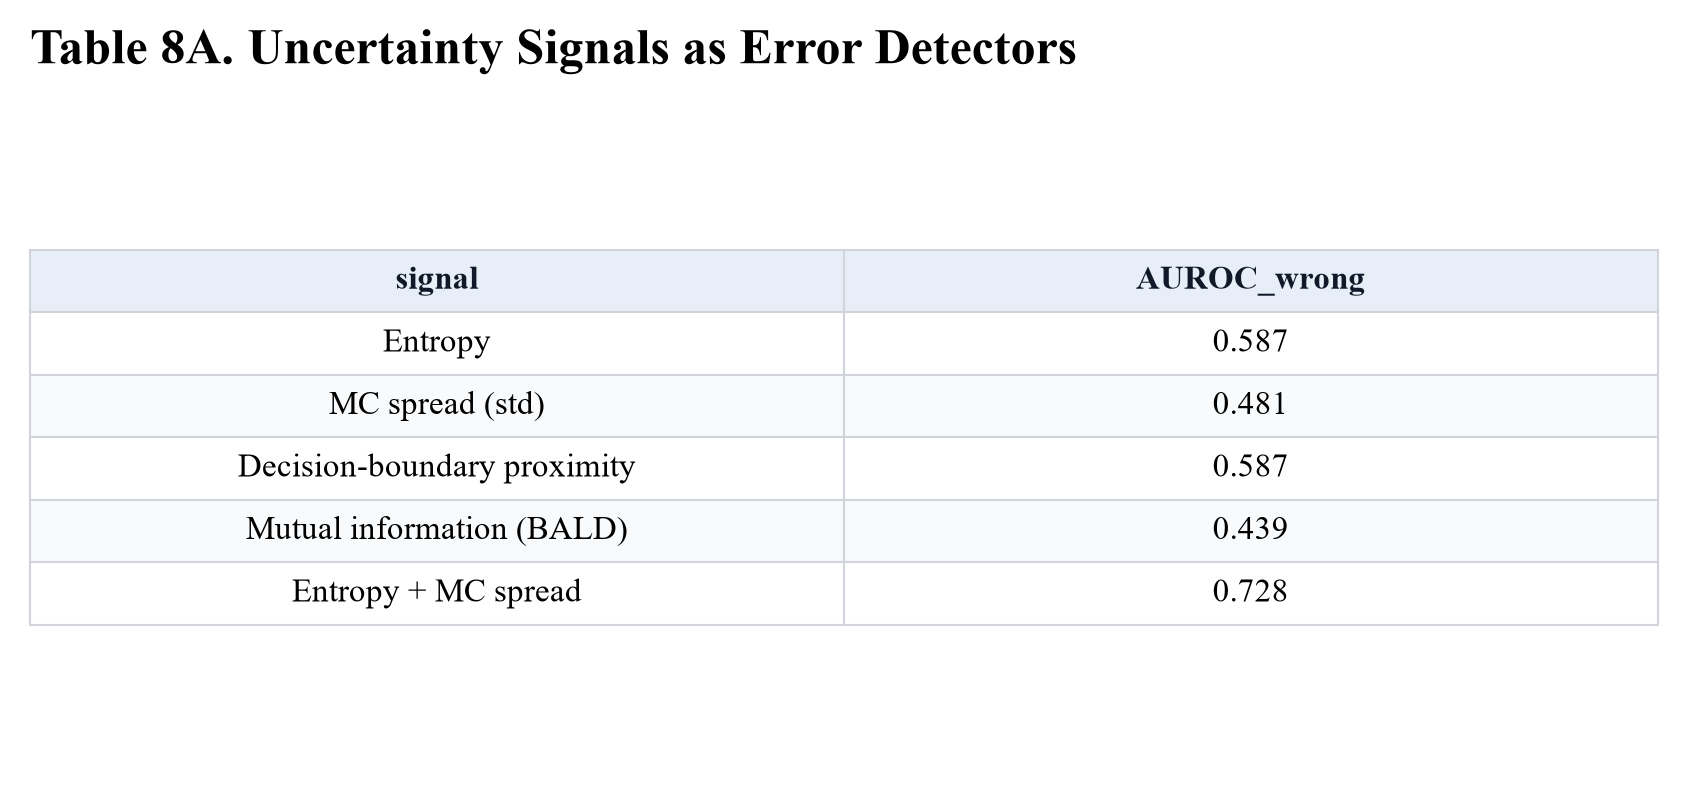

  saved table output_refactored/diagnostics\Table8_uncertainty_signal_metadata.csv


,diagnostic,value
0,max_abs_entropy_reconstruction_error,1.105538e-07
1,spearman_entropy_vs_mc_spread,6.492750e-01
2,wrong_prediction_rate,1.296296e-01


  saved output_refactored/diagnostics\Table8_uncertainty_signal_metadata.png and output_refactored/diagnostics\Table8_uncertainty_signal_metadata.pdf


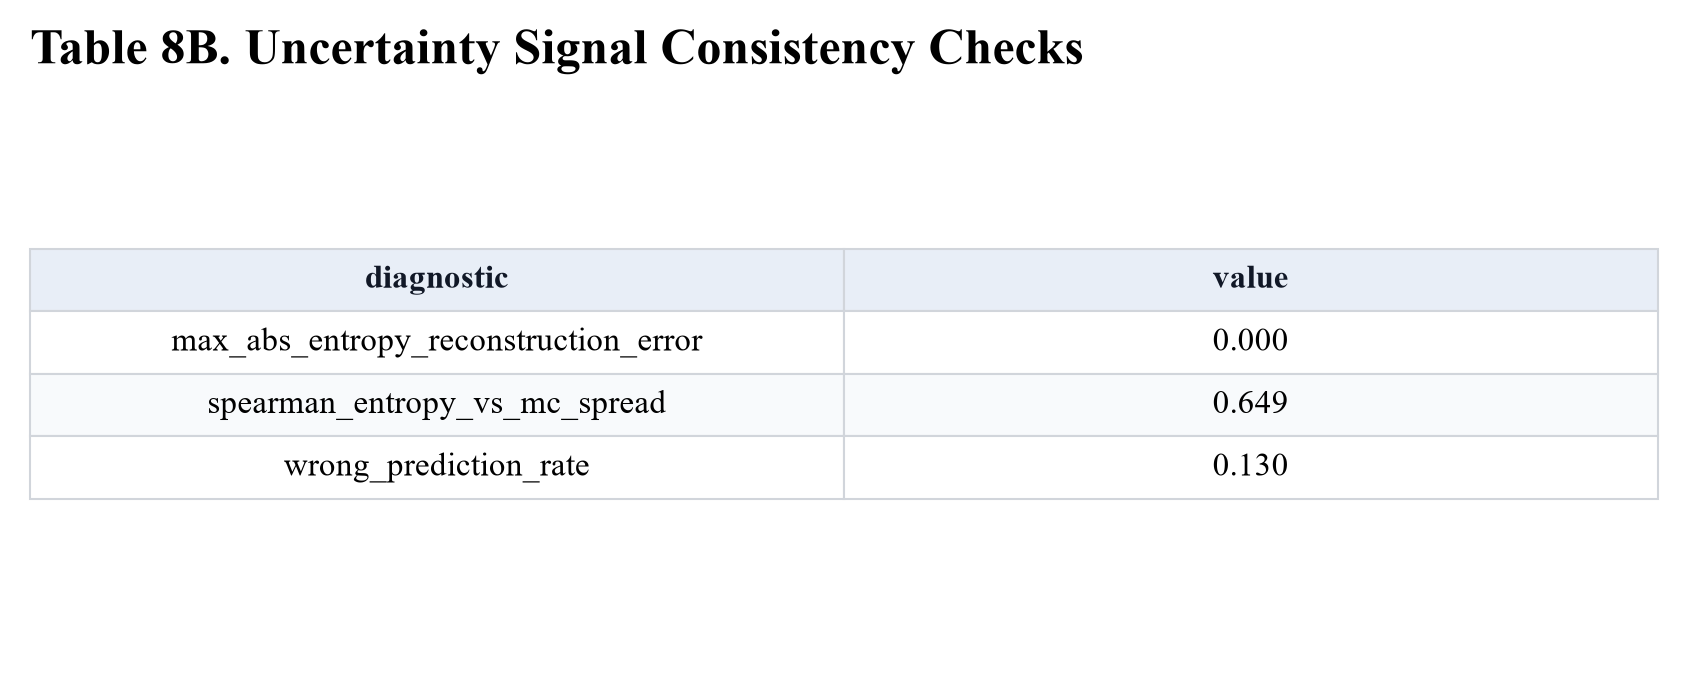

  saved output_refactored/diagnostics\Fig8A_uncertainty_signal_auroc.png and output_refactored/diagnostics\Fig8A_uncertainty_signal_auroc.pdf


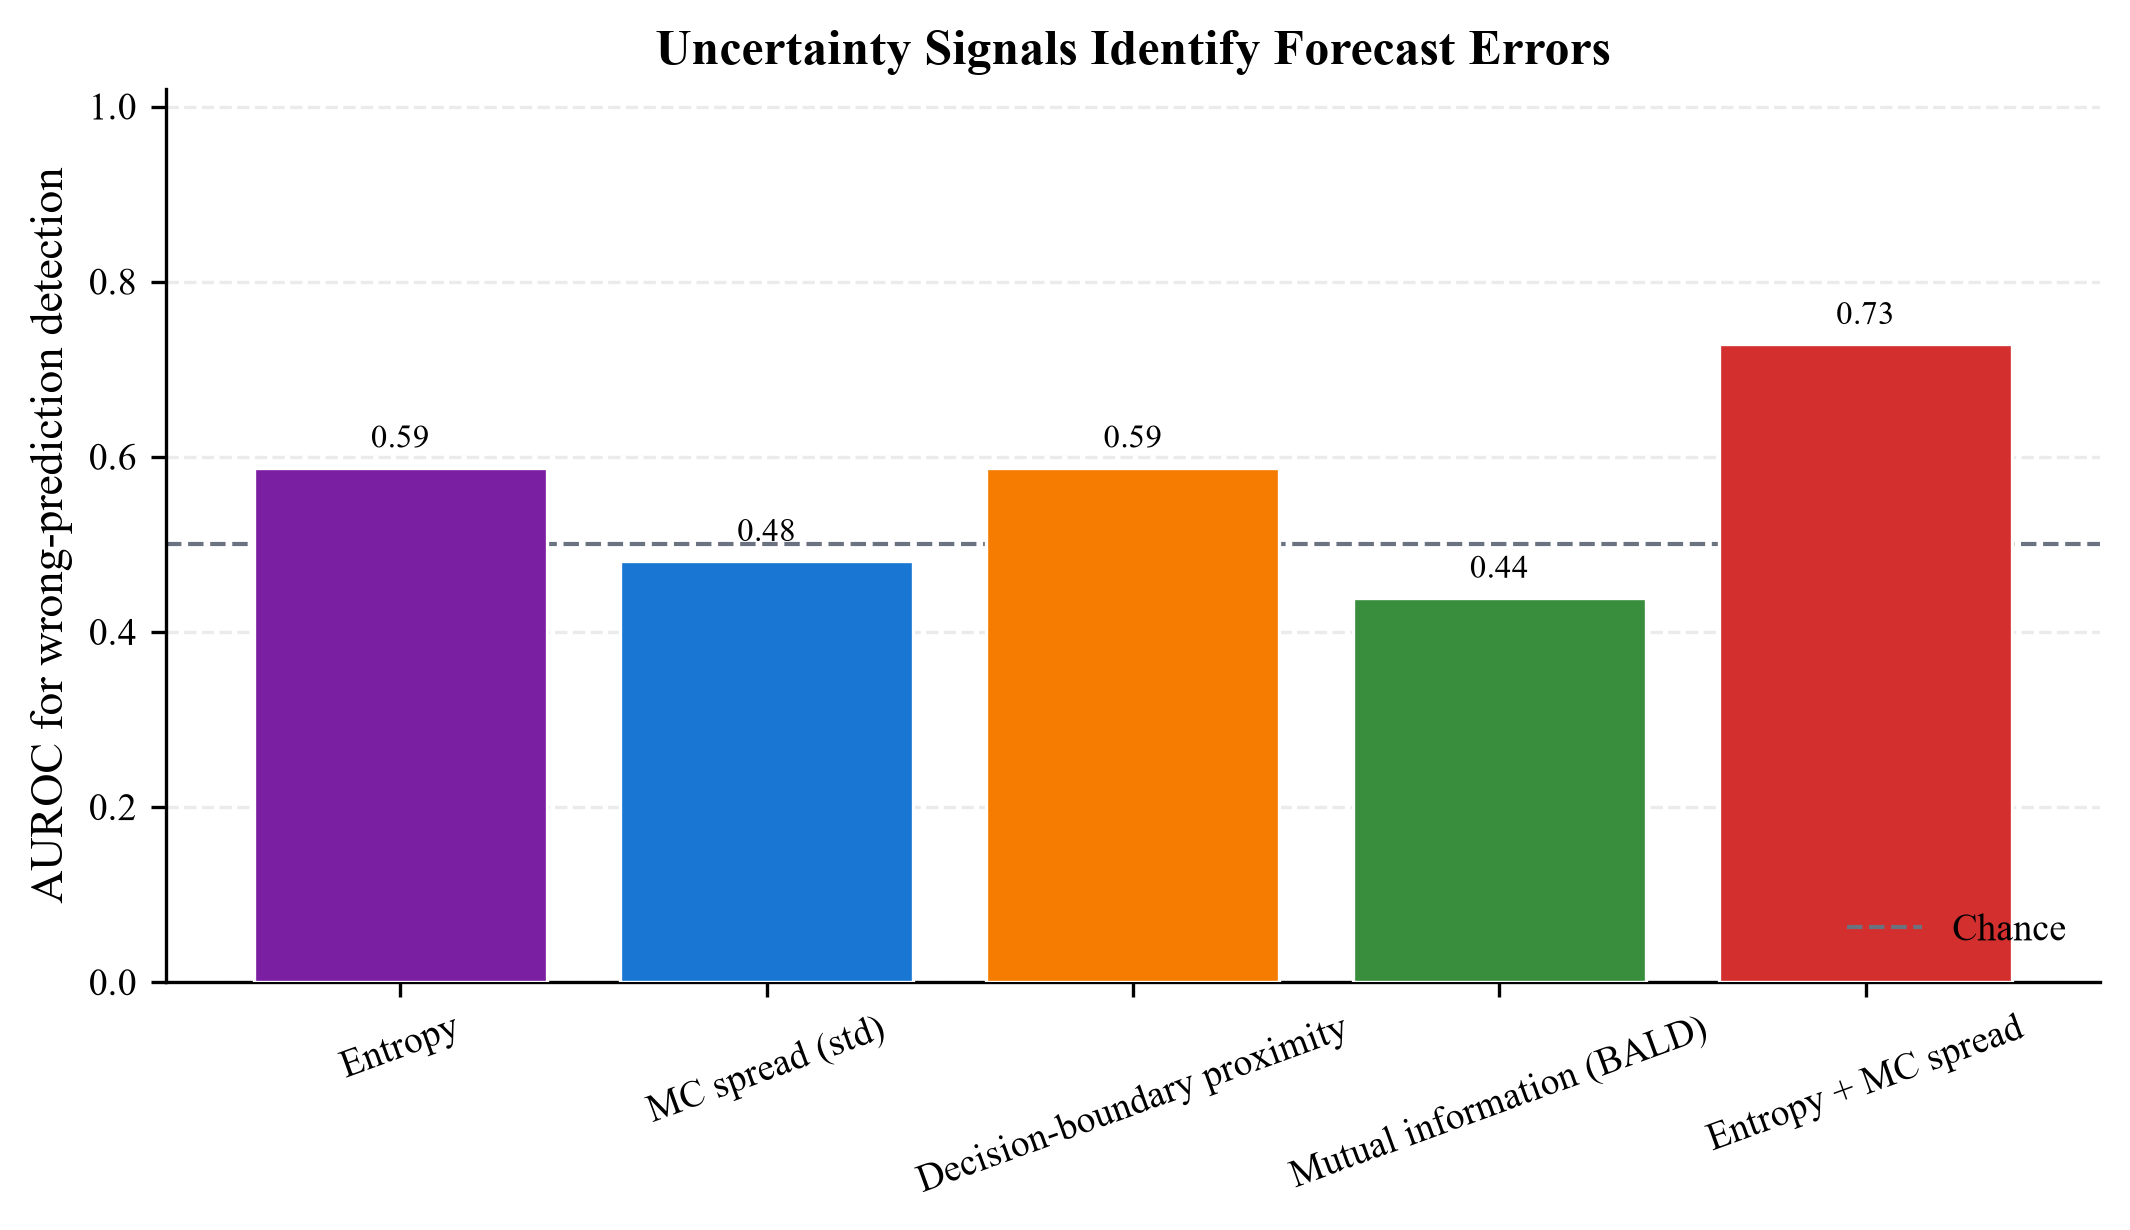

  saved output_refactored/diagnostics\Fig8B_entropy_vs_mc_spread.png and output_refactored/diagnostics\Fig8B_entropy_vs_mc_spread.pdf


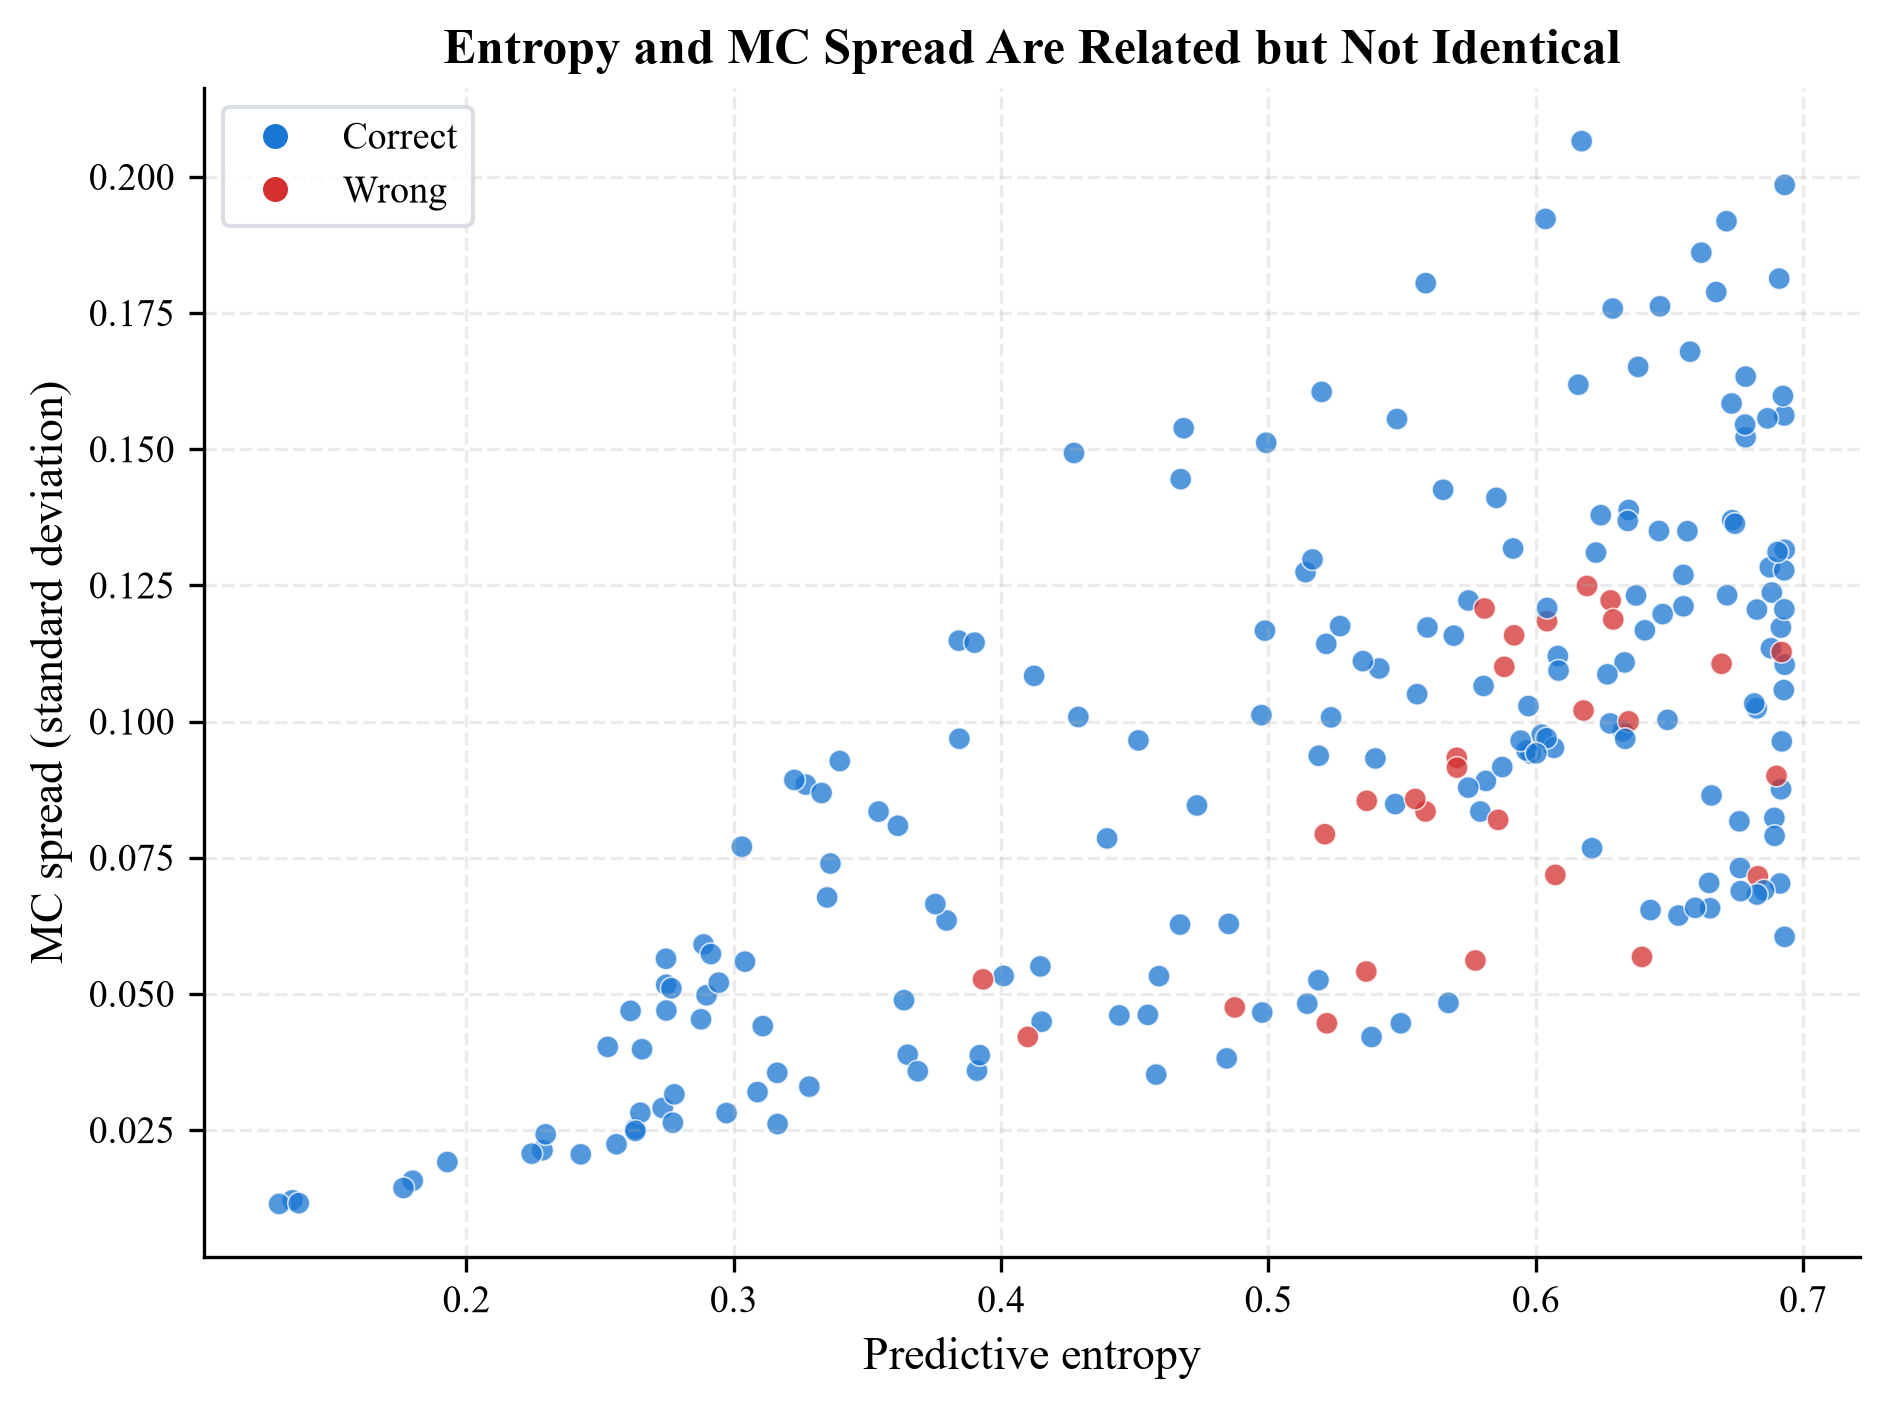

In [3]:
correct = (y_pred_hyb == y_actual).astype(int)
wrong = 1 - correct

# (1) entropy == H(y_mean)?
eps = 1e-10
ymc = np.clip(y_mean, eps, 1 - eps)
H = -(ymc * np.log(ymc) + (1 - ymc) * np.log(1 - ymc))
entropy_delta = float(np.max(np.abs(H - entropy)))
entropy_std_rho = float(spearmanr(entropy, y_std).statistic)
print(f'max|H(y_mean) - stored entropy| = {entropy_delta:.2e}')
print(f'Spearman(entropy, y_std) = {entropy_std_rho:.3f}')

# (2) AUROC of each signal for detecting wrong predictions.
rows = []
signals = {
    'Entropy': entropy,
    'MC spread (std)': y_std,
    'Decision-boundary proximity': -np.abs(y_mean - 0.5),
}
# Mutual information is the genuine ensemble-disagreement signal (BALD). The old
# 'Entropy' column is H(mean) -- a deterministic transform of the point estimate,
# so it tracks decision-boundary proximity exactly; MI should separate from it.
if mutual_information is not None:
    signals['Mutual information (BALD)'] = mutual_information
for name, sig in signals.items():
    rows.append({'signal': name, 'AUROC_wrong': safe_auroc(wrong, sig)})

if len(np.unique(wrong)) > 1:
    Xc = StandardScaler().fit_transform(np.column_stack([entropy, y_std]))
    lr = LogisticRegression(random_state=SEED).fit(Xc, wrong)
    rows.append({'signal': 'Entropy + MC spread',
                 'AUROC_wrong': safe_auroc(wrong, lr.predict_proba(Xc)[:, 1])})
else:
    rows.append({'signal': 'Entropy + MC spread', 'AUROC_wrong': np.nan})

audit = pd.DataFrame(rows)
metadata = pd.DataFrame([
    {'diagnostic': 'max_abs_entropy_reconstruction_error', 'value': entropy_delta},
    {'diagnostic': 'spearman_entropy_vs_mc_spread', 'value': entropy_std_rho},
    {'diagnostic': 'wrong_prediction_rate', 'value': float(wrong.mean())},
])
save_table(audit, 'Table8_uncertainty_signal_auroc.csv',
           'Table 8A. Uncertainty Signals as Error Detectors')
save_table(metadata, 'Table8_uncertainty_signal_metadata.csv',
           'Table 8B. Uncertainty Signal Consistency Checks')

# Figure A: AUROC bars.
fig, ax = plt.subplots(figsize=(7.2, 4.2))
plot_df = audit.dropna(subset=['AUROC_wrong']).copy()
bars = ax.bar(plot_df['signal'], plot_df['AUROC_wrong'],
              color=[COLORS['purple'], COLORS['blue'], COLORS['orange'], COLORS['green'], COLORS['red']][:len(plot_df)],
              edgecolor='white', linewidth=0.8, zorder=3)
ax.axhline(0.5, color=COLORS['gray'], linestyle='--', linewidth=1, label='Chance')
ax.set_ylim(0, 1.02)
ax.set_ylabel('AUROC for wrong-prediction detection')
ax.set_title('Uncertainty Signals Identify Forecast Errors', fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
ax.tick_params(axis='x', rotation=20)
add_bar_labels(ax, bars, fmt='{:.2f}', dy=0.015)
ax.legend(frameon=False, loc='lower right')
plt.tight_layout()
savefig(fig, 'Fig8A_uncertainty_signal_auroc')
plt.show()

# Figure B: entropy vs MC spread, colored by correctness.
fig, ax = plt.subplots(figsize=(6.4, 4.8))
colors = np.where(wrong == 1, COLORS['red'], COLORS['blue'])
ax.scatter(entropy, y_std, c=colors, s=28, alpha=0.75, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Predictive entropy')
ax.set_ylabel('MC spread (standard deviation)')
ax.set_title('Entropy and MC Spread Are Related but Not Identical', fontweight='bold')
ax.grid(alpha=0.25, linestyle='--')
handles = [plt.Line2D([0], [0], marker='o', color='w', label='Correct', markerfacecolor=COLORS['blue'], markersize=7),
           plt.Line2D([0], [0], marker='o', color='w', label='Wrong', markerfacecolor=COLORS['red'], markersize=7)]
ax.legend(handles=handles, frameon=True, edgecolor='#D1D5DB')
plt.tight_layout()
savefig(fig, 'Fig8B_entropy_vs_mc_spread')
plt.show()


## Section C — TRUE uncertainty decomposition

Splits total predictive variance into a **driver-state (aleatoric)** component and a
**model-weight (MC-dropout / epistemic)** component via the law of total variance.
Notebook 04b writes `mc_preds` as `(n_samples, n_enkf, n_mc)`; when only notebook
04 has been run, this cell falls back to the available 2-D MC-dropout spread.

  saved table output_refactored/diagnostics\Table8_variance_decomposition_samples.csv


,var_driver,var_model,total_variance,driver_fraction,y_actual,correct
0,0.000107,0.000347,0.000454,0.236002,1,1
1,0.000033,0.000114,0.000147,0.224438,1,1
2,0.000047,0.000199,0.000247,0.192165,1,1
3,0.000072,0.000351,0.000423,0.170126,1,1
4,0.000286,0.000953,0.001239,0.230555,1,1
...,...,...,...,...,...,...
211,0.006788,0.002082,0.008871,0.765248,0,1
212,0.011622,0.002012,0.013634,0.852462,0,1
213,0.016092,0.002123,0.018215,0.883435,0,1
214,0.021384,0.002495,0.023879,0.895509,0,1


  saved table output_refactored/diagnostics\Table8_variance_decomposition_summary.csv


,component,count,mean,std,min,25%,50%,75%,max,spearman_driver_vs_model
0,var_driver,216.0,0.008642,0.008500,0.000009,0.001518,0.007029,0.012641,0.040024,0.423525
1,var_model,216.0,0.001614,0.001122,0.000094,0.000910,0.001257,0.002089,0.005668,0.423525
2,total_variance,216.0,0.010255,0.008800,0.000131,0.002907,0.008649,0.014541,0.042674,0.423525
3,driver_fraction,216.0,0.700676,0.263127,0.063910,0.525244,0.832494,0.902713,0.964475,0.423525


  saved output_refactored/diagnostics\Table8_variance_decomposition_summary.png and output_refactored/diagnostics\Table8_variance_decomposition_summary.pdf


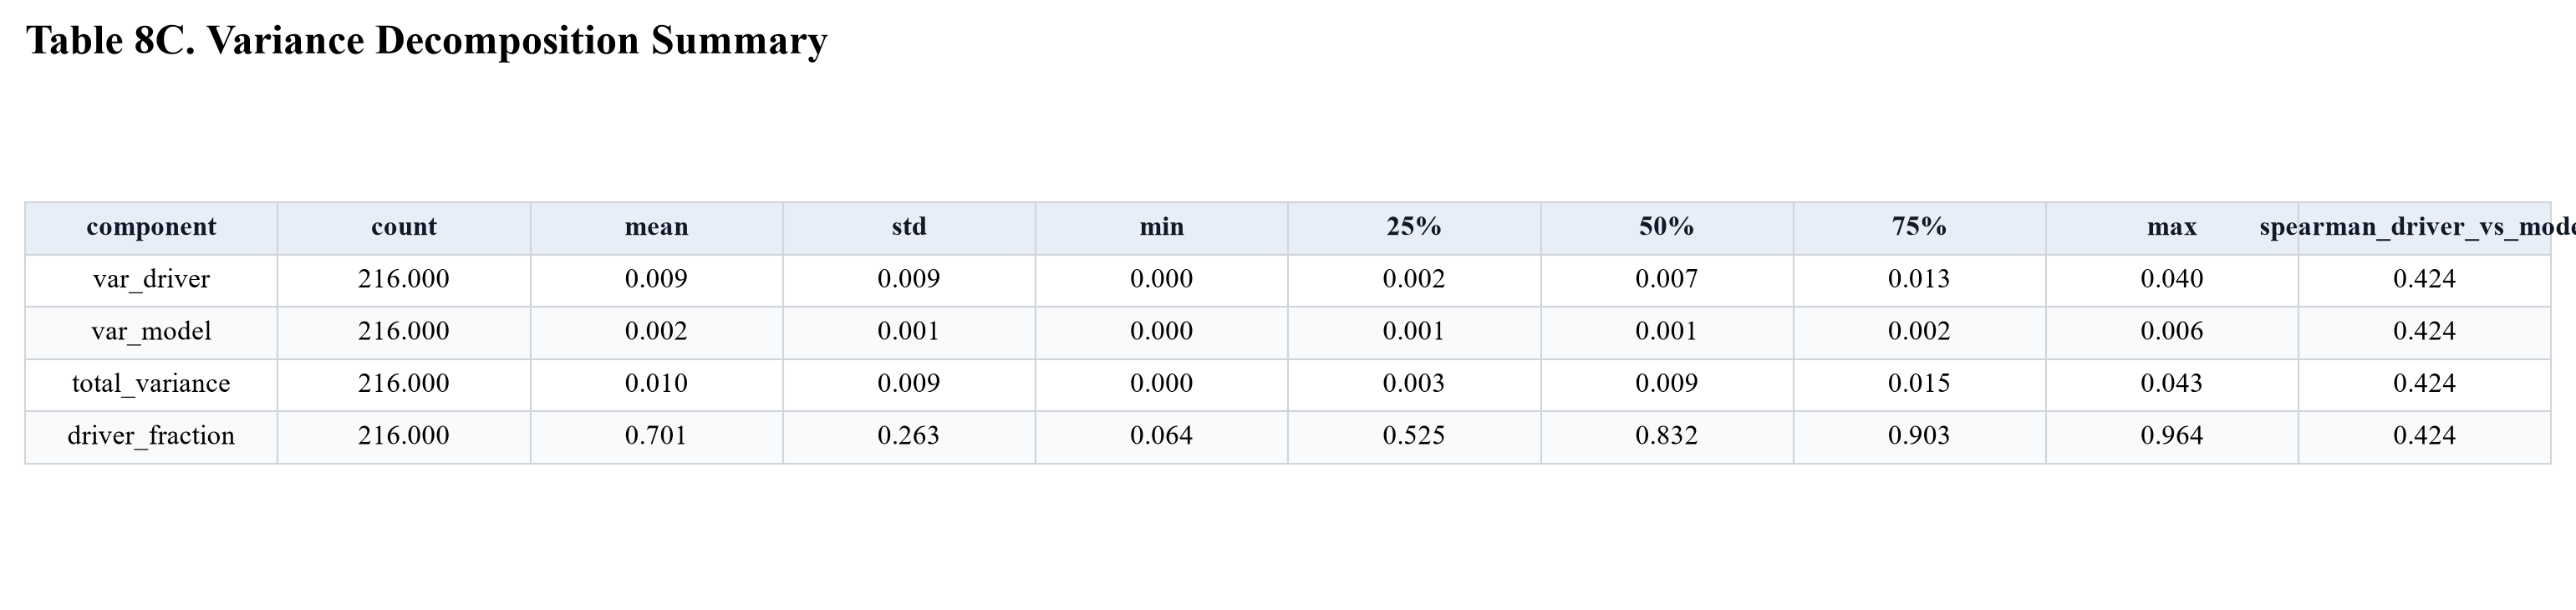

  saved output_refactored/diagnostics\Fig8C_variance_decomposition.png and output_refactored/diagnostics\Fig8C_variance_decomposition.pdf


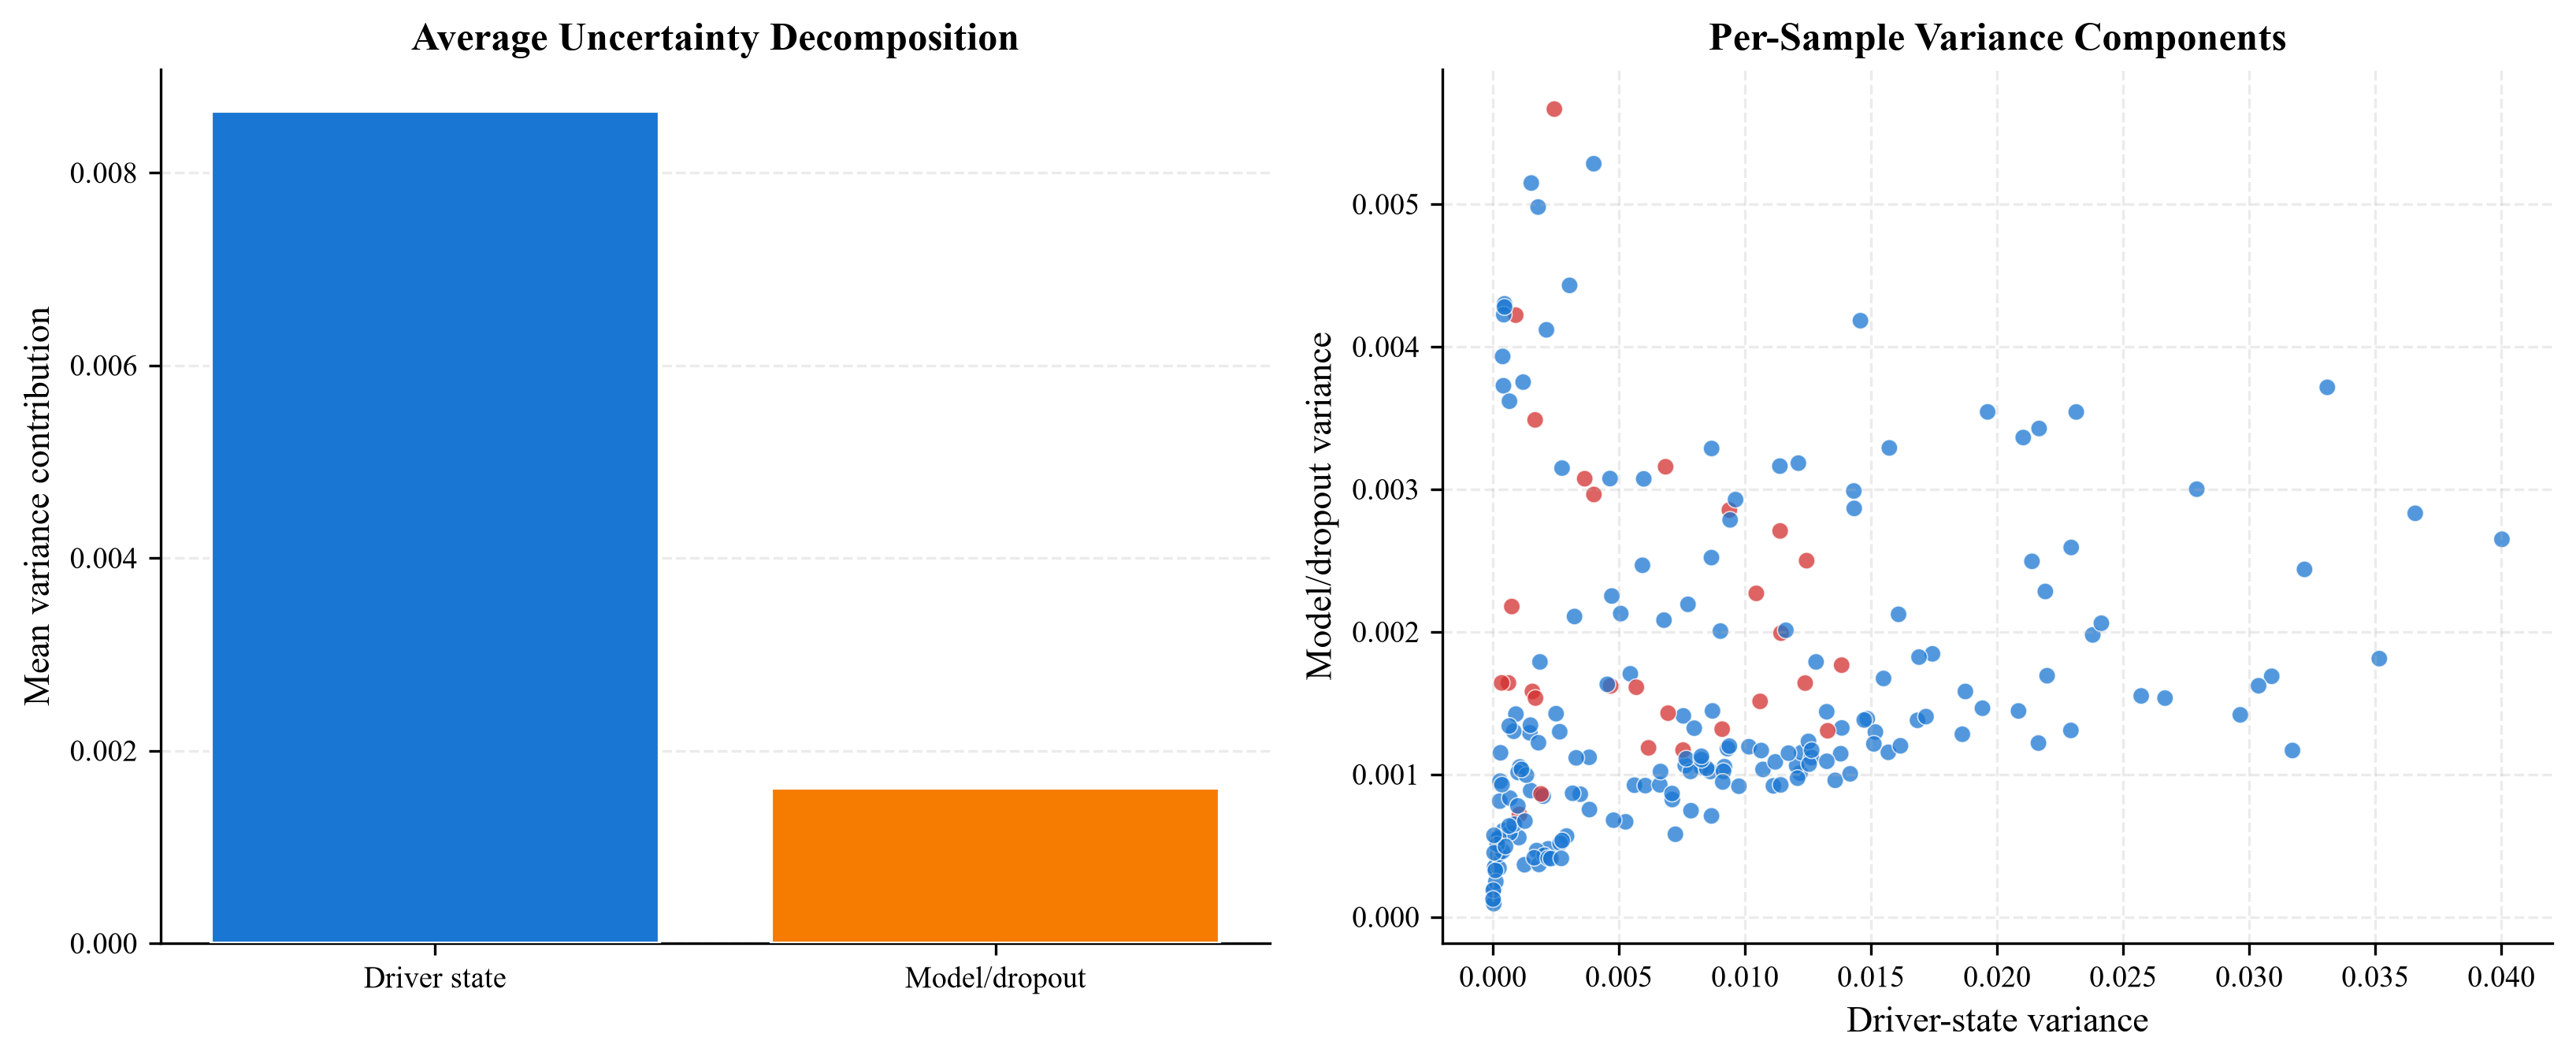

In [4]:
def decompose_variance(mc_tensor):
    # mc_tensor: (n_samples, n_enkf, n_mc) of predicted probabilities
    per_member_mean = mc_tensor.mean(axis=2)
    per_member_var = mc_tensor.var(axis=2)
    var_driver = per_member_mean.var(axis=1)
    var_model = per_member_var.mean(axis=1)
    return var_driver, var_model

if mc_preds is not None and mc_preds.ndim == 3:
    var_driver, var_model = decompose_variance(mc_preds)
    dec = pd.DataFrame({
        'var_driver': var_driver,
        'var_model': var_model,
        'total_variance': var_driver + var_model,
        'driver_fraction': var_driver / np.maximum(var_driver + var_model, 1e-12),
        'y_actual': y_actual[-len(var_driver):],
        'correct': correct[-len(var_driver):],
    })
    save_table(dec, 'Table8_variance_decomposition_samples.csv',
               'Table 8C. Per-Sample Variance Decomposition', render=False)
    dec_summary = dec[['var_driver', 'var_model', 'total_variance', 'driver_fraction']].describe().T.reset_index(names='component')
    dec_summary['spearman_driver_vs_model'] = spearmanr(var_driver, var_model).statistic
    save_table(dec_summary, 'Table8_variance_decomposition_summary.csv',
               'Table 8C. Variance Decomposition Summary')

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    means = [dec['var_driver'].mean(), dec['var_model'].mean()]
    axes[0].bar(['Driver state', 'Model/dropout'], means,
                color=[COLORS['blue'], COLORS['orange']], edgecolor='white', zorder=3)
    axes[0].set_ylabel('Mean variance contribution')
    axes[0].set_title('Average Uncertainty Decomposition', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
    axes[1].scatter(dec['var_driver'], dec['var_model'], c=np.where(dec['correct'] == 1, COLORS['blue'], COLORS['red']),
                    s=26, alpha=0.75, edgecolor='white', linewidth=0.4)
    axes[1].set_xlabel('Driver-state variance')
    axes[1].set_ylabel('Model/dropout variance')
    axes[1].set_title('Per-Sample Variance Components', fontweight='bold')
    axes[1].grid(alpha=0.25, linestyle='--')
    plt.tight_layout()
    savefig(fig, 'Fig8C_variance_decomposition')
    plt.show()

elif mc_preds is not None and mc_preds.ndim == 2:
    # Current notebook 04 stores MC-dropout samples as (n_samples, n_mc). A true
    # driver/model decomposition requires a 3-D tensor, so report the available
    # MC-dropout spread as the publication-ready uncertainty diagnostic.
    mc_mean = mc_preds.mean(axis=1)
    mc_std = mc_preds.std(axis=1)
    mc_var = mc_preds.var(axis=1)
    dec = pd.DataFrame({
        'mc_mean': mc_mean,
        'mc_std': mc_std,
        'mc_variance': mc_var,
        'y_actual': y_actual[-len(mc_mean):],
        'correct': correct[-len(mc_mean):],
    })
    save_table(dec, 'Table8_mc_dropout_uncertainty_samples.csv',
               'Table 8C. Per-Sample MC-Dropout Uncertainty', render=False)
    summary = dec.groupby(['y_actual', 'correct'], dropna=False).agg(
        n=('mc_std', 'size'), mean_mc_std=('mc_std', 'mean'), median_mc_std=('mc_std', 'median'),
        mean_probability=('mc_mean', 'mean'), mean_variance=('mc_variance', 'mean')
    ).reset_index()
    note = pd.DataFrame([{'note': 'mc_predictions.npy is 2-D, so true driver-vs-model variance decomposition is unavailable; table reports MC-dropout uncertainty instead.'}])
    save_table(summary, 'Table8_mc_dropout_uncertainty_summary.csv',
               'Table 8C. MC-Dropout Uncertainty by Outcome')
    save_table(note, 'Table8_variance_decomposition_note.csv',
               'Table 8C Note', render=True)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    groups = [('Correct', dec.loc[dec['correct'] == 1, 'mc_std']),
              ('Wrong', dec.loc[dec['correct'] == 0, 'mc_std'])]
    axes[0].boxplot([g[1] for g in groups], labels=[g[0] for g in groups], patch_artist=True,
                    boxprops={'facecolor': COLORS['light_gray'], 'edgecolor': COLORS['dark']},
                    medianprops={'color': COLORS['red'], 'linewidth': 1.5})
    axes[0].set_ylabel('MC spread (standard deviation)')
    axes[0].set_title('MC Spread by Forecast Correctness', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.25, linestyle='--')
    axes[1].scatter(dec['mc_mean'], dec['mc_std'], c=np.where(dec['correct'] == 1, COLORS['blue'], COLORS['red']),
                    s=28, alpha=0.75, edgecolor='white', linewidth=0.4)
    axes[1].axvline(THRESH, color=COLORS['gray'], linestyle='--', linewidth=1, label=f'Threshold {THRESH:.2f}')
    axes[1].set_xlabel('Mean predicted probability')
    axes[1].set_ylabel('MC spread (standard deviation)')
    axes[1].set_title('Uncertainty Across the Probability Range', fontweight='bold')
    axes[1].grid(alpha=0.25, linestyle='--')
    axes[1].legend(frameon=False)
    plt.tight_layout()
    savefig(fig, 'Fig8C_mc_dropout_uncertainty')
    plt.show()
else:
    note = pd.DataFrame([{'note': 'mc_predictions.npy is absent; uncertainty decomposition figure was skipped.'}])
    save_table(note, 'Table8_variance_decomposition_note.csv', 'Table 8C Note')


## Section D — Baseline agreement stratification (Analysis 4)

Counts how many of the four simple baselines predict bloom per sample, stratifies the
test set, and reports per-stratum performance. Needs `simple_baselines_preds.npz`.

  saved table output_refactored/diagnostics\Table8_stratified_performance.csv


,stratum,n,hybrid_acc,hybrid_recall,mean_y_std,bloom_rate
0,high,131,0.954198,0.250000,0.112049,0.030534
1,moderate,85,0.741176,0.787879,0.059417,0.776471


  saved output_refactored/diagnostics\Table8_stratified_performance.png and output_refactored/diagnostics\Table8_stratified_performance.pdf


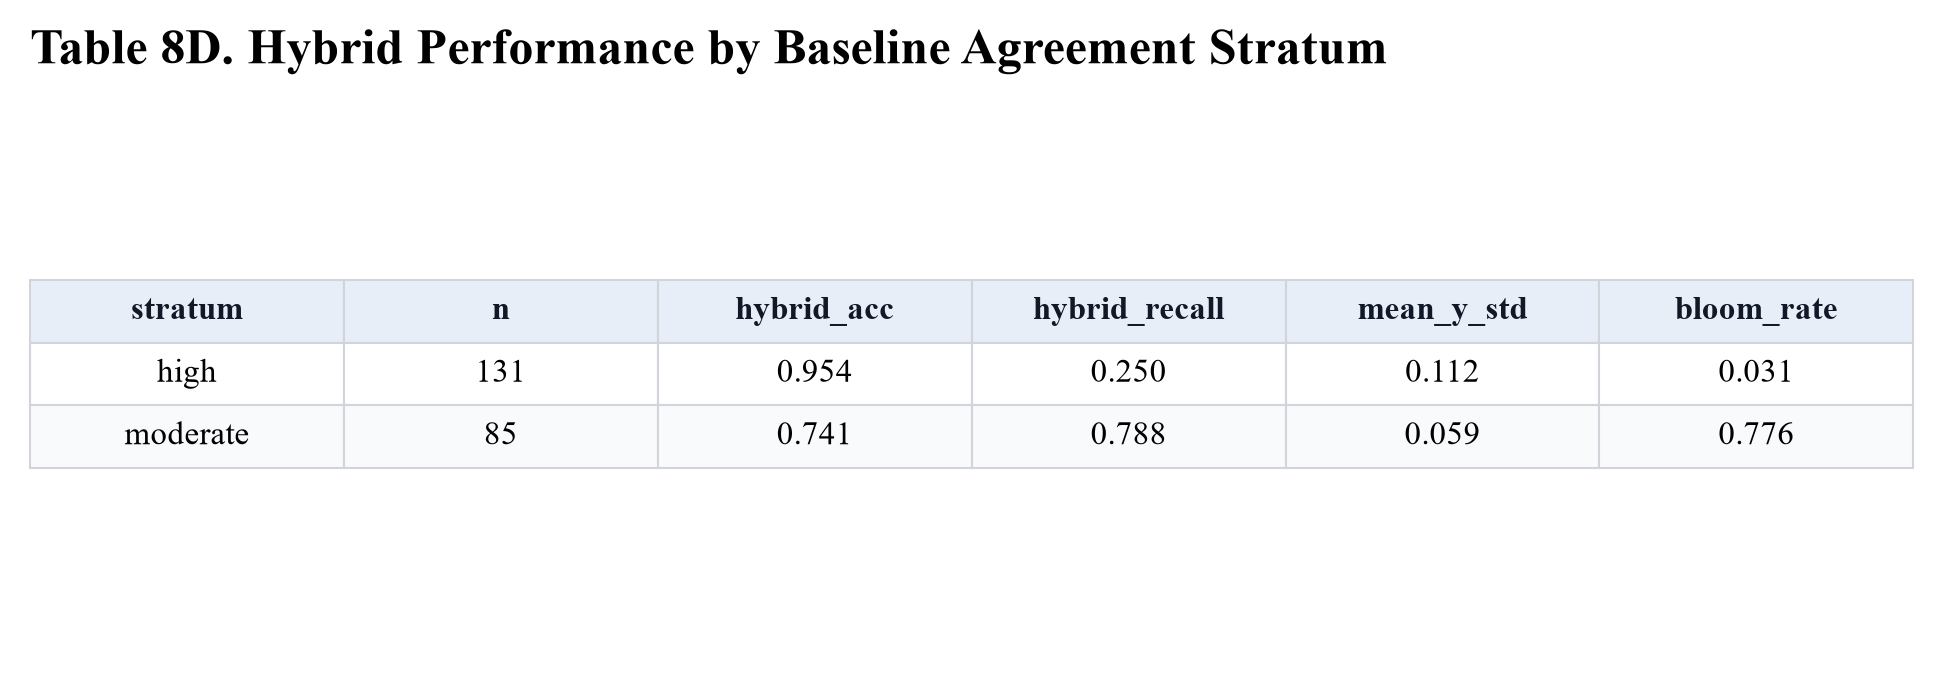

  saved output_refactored/diagnostics\Fig8D_baseline_agreement_strata.png and output_refactored/diagnostics\Fig8D_baseline_agreement_strata.pdf


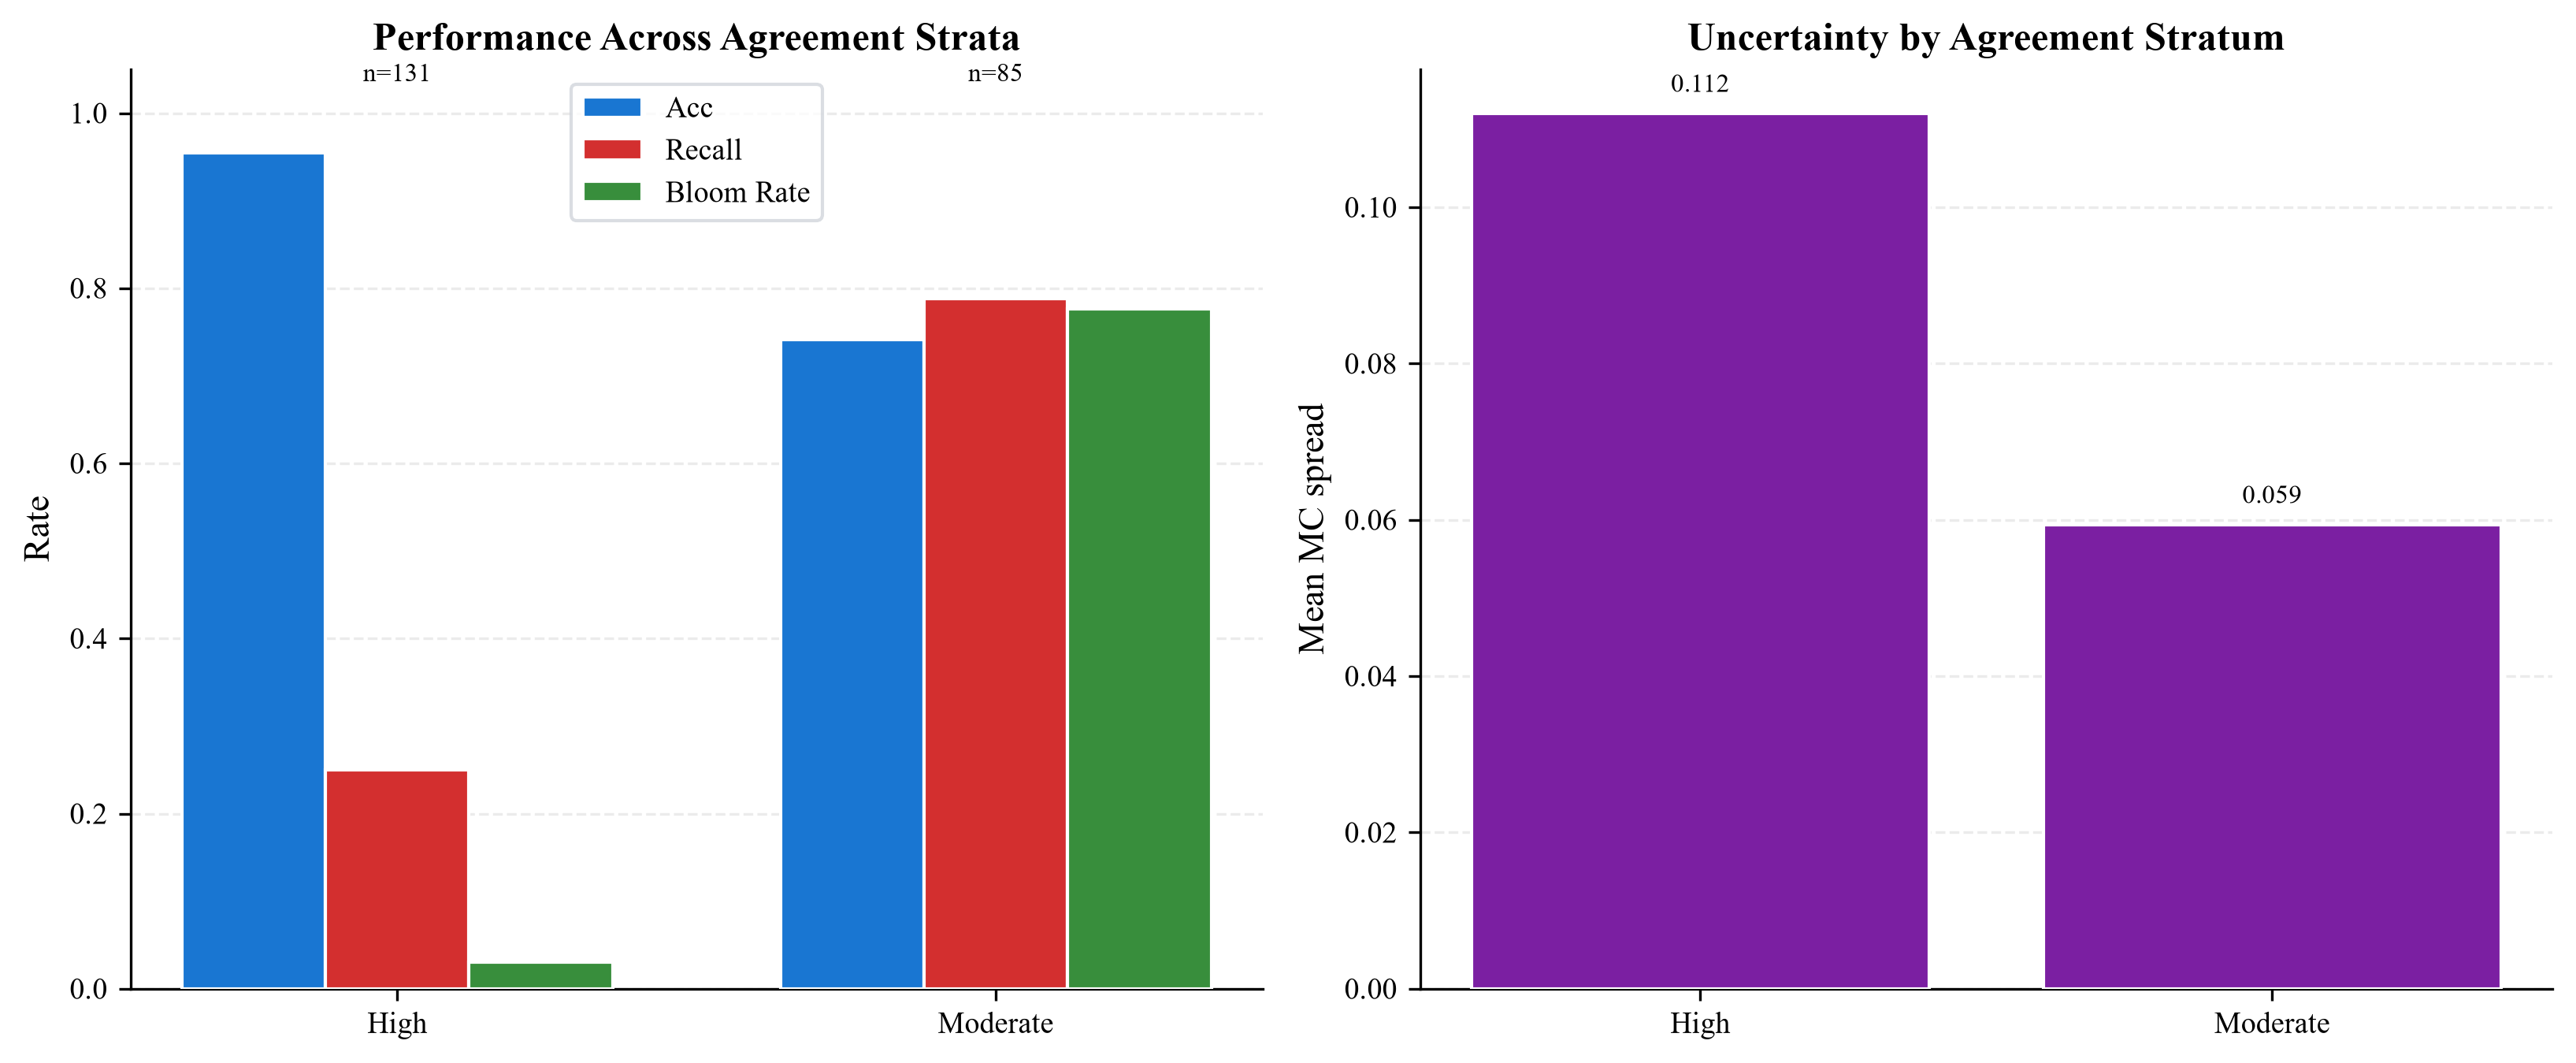

In [5]:
SIMPLE = ['Climatology', 'Persistence', 'Logistic_Regression', 'Random_Forest']
have = [s for s in SIMPLE if s in baseline_streams and baseline_streams[s]['y_pred'] is not None]

# Reconcile baseline lengths with the hybrid stream. Simple baselines may be
# SHORTER than the hybrid stream (some require their own lookback), so [-N:]
# would silently leave them at their native length and the agreement masks
# would not match y_actual/y_pred_hyb (e.g. mask size 216 vs array size 232).
# Compute Nb = min length across the hybrid arrays and every baseline, then
# build baseline-aligned views (yb_*) used throughout Sections D/E/F.
if len(have) >= 2:
    _baseline_lens = [len(np.asarray(baseline_streams[s]['y_pred']).flatten()) for s in have]
    Nb = min([N] + _baseline_lens)
    if Nb != N:
        print(f'  [align] baseline streams -> common length Nb={Nb} '
              f'(hybrid N={N}, baselines={_baseline_lens}).')
    preds = np.column_stack(
        [np.asarray(baseline_streams[s]['y_pred']).flatten()[-Nb:] for s in have]
    )
    # Baseline-aligned views of the hybrid arrays.
    yb_actual   = y_actual[-Nb:]
    yb_pred_hyb = y_pred_hyb[-Nb:]
    yb_std      = y_std[-Nb:]
    yb_entropy  = entropy[-Nb:]

    agree_count = preds.sum(axis=1)
    k = len(have)
    stratum = np.where((agree_count == k) | (agree_count == 0), 'high',
              np.where((agree_count == k - 1) | (agree_count == 1), 'moderate', 'low'))
    out = []
    for s in ['high', 'moderate', 'low']:
        m = stratum == s
        if m.sum() == 0:
            continue
        out.append({
            'stratum': s,
            'n': int(m.sum()),
            'hybrid_acc': accuracy_score(yb_actual[m], yb_pred_hyb[m]),
            'hybrid_recall': recall_score(yb_actual[m], yb_pred_hyb[m], zero_division=0),
            'mean_y_std': yb_std[m].mean(),
            'bloom_rate': yb_actual[m].mean(),
        })
    strat = pd.DataFrame(out)
else:
    Nb = N
    preds = None
    agree_count = None
    stratum = np.array(['unavailable'] * N)
    yb_actual = y_actual
    yb_pred_hyb = y_pred_hyb
    yb_std = y_std
    yb_entropy = entropy
    strat = pd.DataFrame(columns=['stratum', 'n', 'hybrid_acc', 'hybrid_recall', 'mean_y_std', 'bloom_rate'])

save_table(strat, 'Table8_stratified_performance.csv',
           'Table 8D. Hybrid Performance by Baseline Agreement Stratum')

if len(strat) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    x = np.arange(len(strat))
    width = 0.24
    for j, metric in enumerate(['hybrid_acc', 'hybrid_recall', 'bloom_rate']):
        axes[0].bar(x + (j - 1) * width, strat[metric], width,
                    label=metric.replace('hybrid_', '').replace('_', ' ').title(),
                    color=METRIC_COLORS[j], edgecolor='white', zorder=3)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(strat['stratum'].str.title())
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel('Rate')
    axes[0].set_title('Performance Across Agreement Strata', fontweight='bold')
    axes[0].legend(frameon=True, edgecolor='#D1D5DB')
    axes[0].grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
    for i, row in strat.iterrows():
        axes[0].text(i, 1.03, f"n={int(row['n'])}", ha='center', va='bottom', fontsize=8)
    bars = axes[1].bar(strat['stratum'].str.title(), strat['mean_y_std'],
                       color=COLORS['purple'], edgecolor='white', zorder=3)
    axes[1].set_ylabel('Mean MC spread')
    axes[1].set_title('Uncertainty by Agreement Stratum', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
    add_bar_labels(axes[1], bars, fmt='{:.3f}', dy=0.002)
    plt.tight_layout()
    savefig(fig, 'Fig8D_baseline_agreement_strata')
    plt.show()
else:
    print('Need >=2 simple baselines with y_pred. Run notebook 03 first.')


## Section E — Spread-based triage (Analysis 5, reframed)

Because `entropy` is collinear with `y_std`, the original 2-axis (`y_std`x`entropy`)
triage is degenerate (verified: only ~11/230 samples land off-diagonal). The honest
version uses **`y_std` (real ensemble spread) crossed with baseline agreement**, which
are genuinely independent signals.

  saved table output_refactored/diagnostics\Table8_triage_quadrants.csv


,category,n,accuracy,recall,mean_y_std,bloom_rate
0,confident_agree,108,0.851852,0.894737,0.055464,0.527778
1,spread_only,108,0.888889,0.153846,0.127211,0.120370


  saved output_refactored/diagnostics\Table8_triage_quadrants.png and output_refactored/diagnostics\Table8_triage_quadrants.pdf


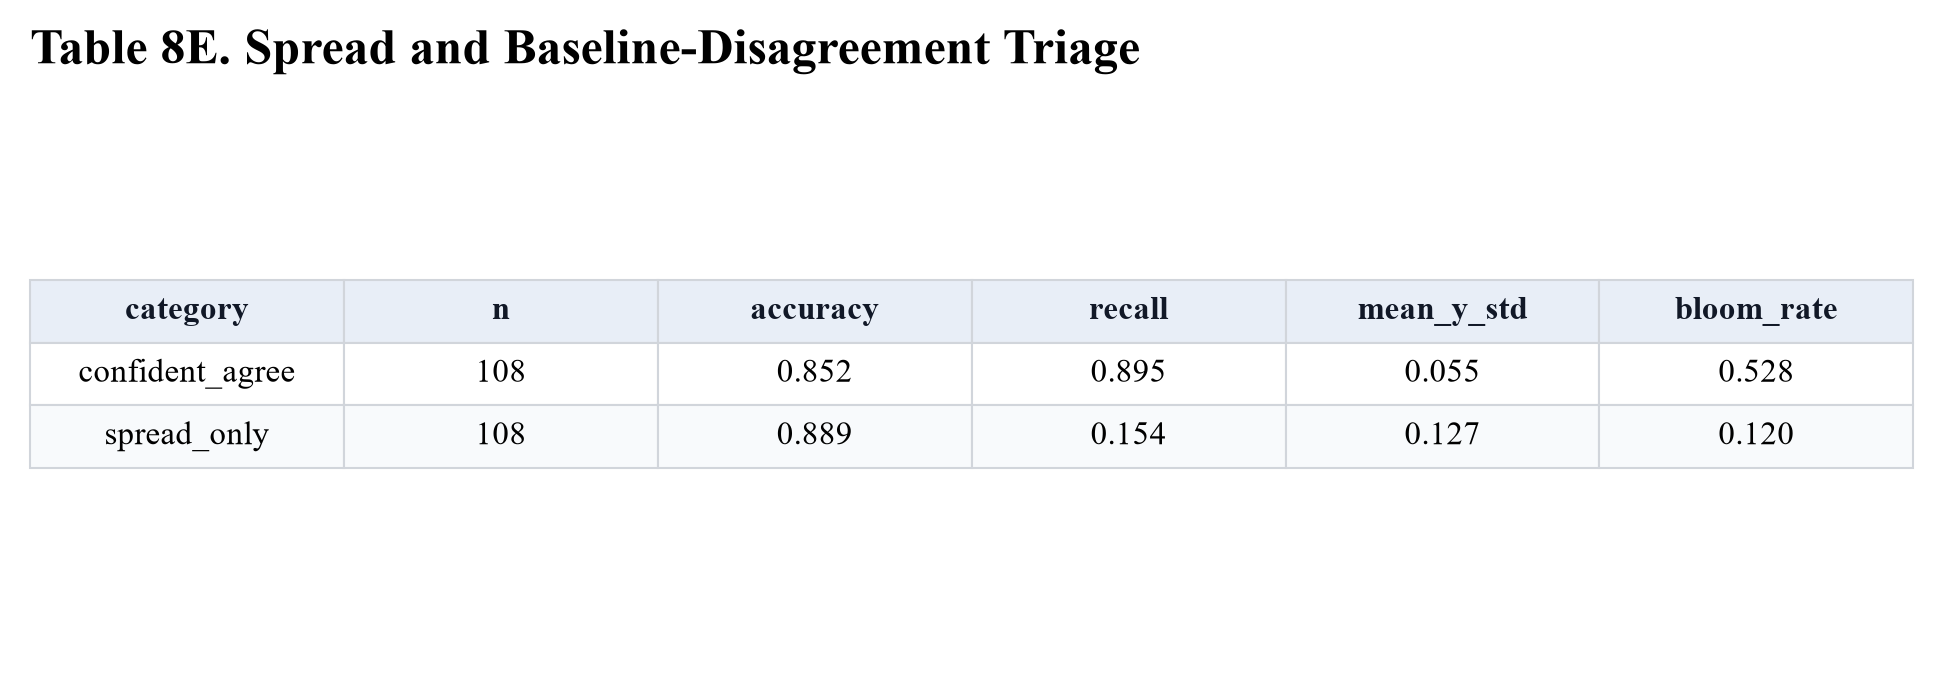

  saved output_refactored/diagnostics\Fig8E_triage_quadrants.png and output_refactored/diagnostics\Fig8E_triage_quadrants.pdf


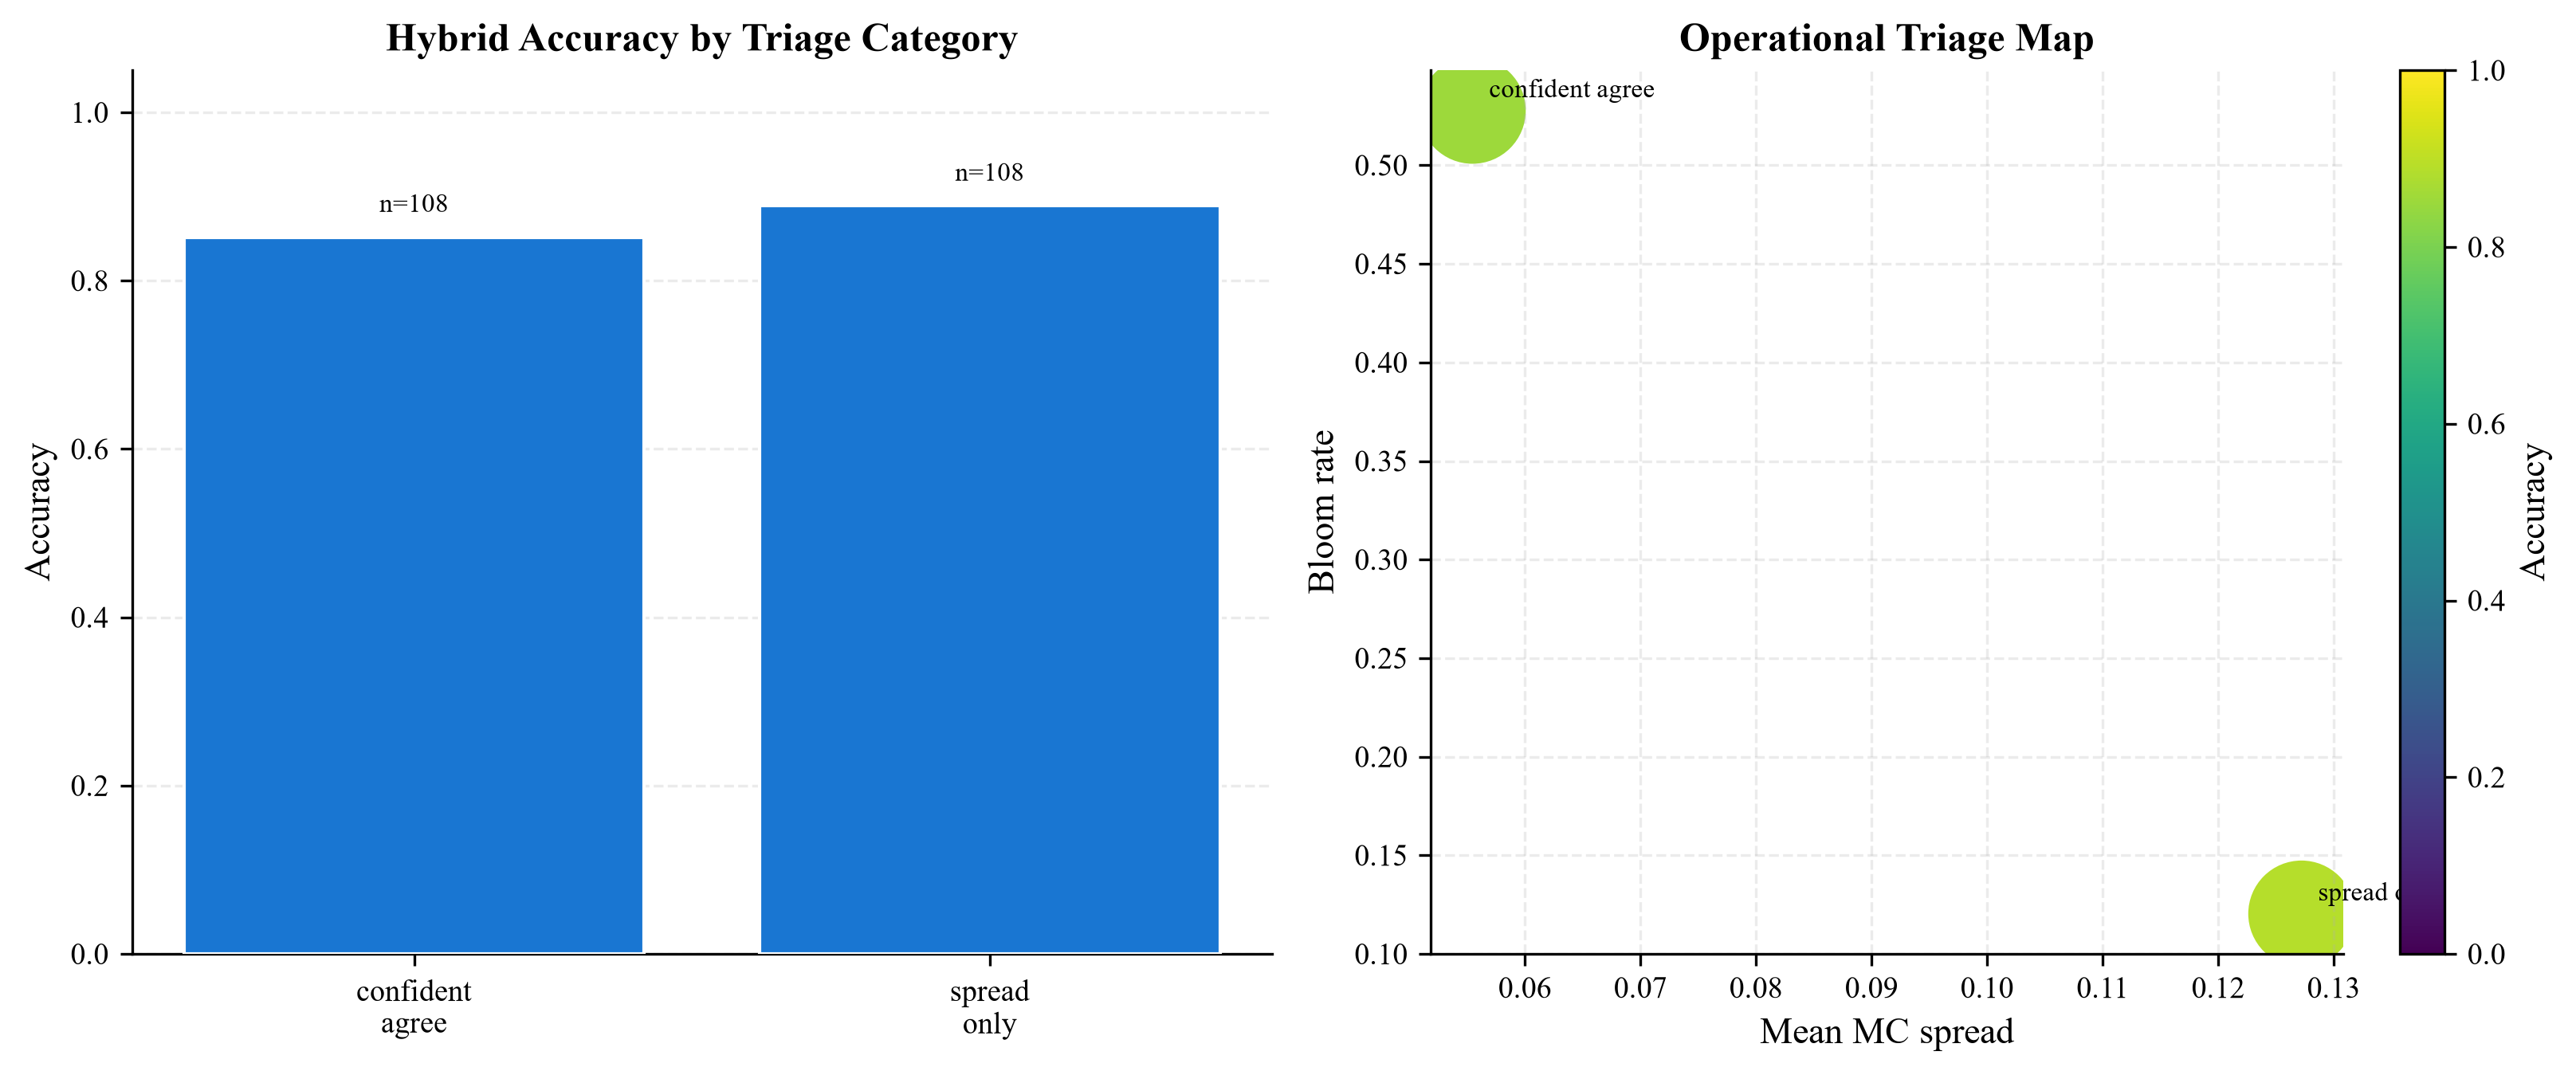

In [6]:
if len(have) >= 2:
    # Use baseline-aligned views (length Nb) so spread, agreement, and the
    # hybrid metrics all share the same sample axis.
    med = np.median(yb_std)
    hi_spread = yb_std >= med
    lo_agree = (stratum == 'low')
    cats = {
        'confident_agree': (~hi_spread) & (~lo_agree),
        'spread_only': (hi_spread) & (~lo_agree),
        'disagree_only': (~hi_spread) & (lo_agree),
        'both_uncertain': (hi_spread) & (lo_agree),
    }
    out = []
    for name, msk in cats.items():
        if msk.sum() == 0:
            continue
        out.append({
            'category': name,
            'n': int(msk.sum()),
            'accuracy': accuracy_score(yb_actual[msk], yb_pred_hyb[msk]),
            'recall': recall_score(yb_actual[msk], yb_pred_hyb[msk], zero_division=0),
            'mean_y_std': yb_std[msk].mean(),
            'bloom_rate': yb_actual[msk].mean(),
        })
    tri = pd.DataFrame(out)
else:
    tri = pd.DataFrame(columns=['category', 'n', 'accuracy', 'recall', 'mean_y_std', 'bloom_rate'])

save_table(tri, 'Table8_triage_quadrants.csv', 'Table 8E. Spread and Baseline-Disagreement Triage')

if len(tri) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    order = ['confident_agree', 'spread_only', 'disagree_only', 'both_uncertain']
    tri_plot = tri.set_index('category').reindex([c for c in order if c in tri['category'].values]).reset_index()
    x = np.arange(len(tri_plot))
    bars = axes[0].bar(x, tri_plot['accuracy'], color=COLORS['blue'], edgecolor='white', zorder=3)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([s.replace('_', '\n') for s in tri_plot['category']])
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Hybrid Accuracy by Triage Category', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
    for i, row in tri_plot.iterrows():
        axes[0].text(i, row['accuracy'] + 0.03, f"n={int(row['n'])}", ha='center', fontsize=8)
    sc = axes[1].scatter(tri_plot['mean_y_std'], tri_plot['bloom_rate'],
                         s=np.maximum(tri_plot['n'], 1) * 10,
                         c=tri_plot['accuracy'], cmap='viridis', vmin=0, vmax=1,
                         edgecolor='white', linewidth=0.8)
    for _, row in tri_plot.iterrows():
        axes[1].annotate(row['category'].replace('_', ' '),
                         (row['mean_y_std'], row['bloom_rate']),
                         xytext=(5, 4), textcoords='offset points', fontsize=8)
    axes[1].set_xlabel('Mean MC spread')
    axes[1].set_ylabel('Bloom rate')
    axes[1].set_title('Operational Triage Map', fontweight='bold')
    axes[1].grid(alpha=0.25, linestyle='--')
    cbar = fig.colorbar(sc, ax=axes[1])
    cbar.set_label('Accuracy')
    plt.tight_layout()
    savefig(fig, 'Fig8E_triage_quadrants')
    plt.show()
else:
    print('Skipped triage figure (needs >=2 simple baselines).')


## Section F — Tiered escalation system (Analysis 6)

If >=3 of 4 baselines agree, output the majority vote; else defer to the hybrid at its
tuned threshold. Reports composite metrics and the escalation fraction.

In [7]:
if len(have) == 4:
    # All arrays here must share the baseline-aligned length Nb: preds is Nb,
    # so the hybrid fallback and the ground truth use the yb_* views too.
    maj = (preds.sum(axis=1) >= 2).astype(int)
    strong = np.isin(preds.sum(axis=1), [0, 1, 3, 4])
    composite = np.where(strong, maj, yb_pred_hyb)
    esc_frac = float((~strong).mean())
    rows = [
        {'model': 'Hybrid only',
         'accuracy': accuracy_score(yb_actual, yb_pred_hyb),
         'precision': precision_score(yb_actual, yb_pred_hyb, zero_division=0),
         'recall': recall_score(yb_actual, yb_pred_hyb, zero_division=0),
         'f1': f1_score(yb_actual, yb_pred_hyb, zero_division=0),
         'escalated_fraction': 1.0},
        {'model': 'Tiered: majority unless uncertain',
         'accuracy': accuracy_score(yb_actual, composite),
         'precision': precision_score(yb_actual, composite, zero_division=0),
         'recall': recall_score(yb_actual, composite, zero_division=0),
         'f1': f1_score(yb_actual, composite, zero_division=0),
         'escalated_fraction': esc_frac},
    ]
    tiered = pd.DataFrame(rows)
else:
    composite = None
    tiered = pd.DataFrame(columns=['model', 'accuracy', 'precision', 'recall', 'f1', 'escalated_fraction'])

save_table(tiered, 'Table8_tiered_system.csv', 'Table 8F. Tiered Escalation System')

if len(tiered) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    x = np.arange(len(metrics))
    width = 0.35
    for i, (_, row) in enumerate(tiered.iterrows()):
        axes[0].bar(x + (i - 0.5) * width, [row[m] for m in metrics], width,
                    label=row['model'], color=[COLORS['blue'], COLORS['green']][i],
                    edgecolor='white', zorder=3)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([m.upper() if m == 'f1' else m.title() for m in metrics])
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel('Score')
    axes[0].set_title('Hybrid vs Tiered Decision System', fontweight='bold')
    axes[0].legend(frameon=True, edgecolor='#D1D5DB')
    axes[0].grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
    bars = axes[1].bar(tiered['model'], tiered['escalated_fraction'],
                       color=[COLORS['blue'], COLORS['orange']], edgecolor='white', zorder=3)
    axes[1].set_ylim(0, 1.05)
    axes[1].set_ylabel('Fraction handled by hybrid')
    axes[1].set_title('Escalation Burden', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
    add_bar_labels(axes[1], bars, fmt='{:.2f}', dy=0.02)
    plt.tight_layout()
    savefig(fig, 'Fig8F_tiered_system')
    plt.show()
else:
    print('Need all four simple baselines. Run notebook 03 first.')


  saved table output_refactored/diagnostics\Table8_tiered_system.csv


,model,accuracy,precision,recall,f1,escalated_fraction


Need all four simple baselines. Run notebook 03 first.


## Section G — Coverage calibration (Analysis 8, corrected)

The original check (binary `y_actual` inside a probability band) is invalid and returns
~0.06. The correct interval-coverage statistic asks, per probability bin, whether the
observed positive frequency lies inside the mean predicted CI for that bin.

  saved table output_refactored/diagnostics\Table8_coverage_calibration.csv


,bin,n,mean_pred,obs_freq,ci_lo,ci_hi,covered
0,0,22,0.092799,0.000000,0.025604,0.286290,False
1,1,21,0.192478,0.000000,0.054732,0.521273,False
2,2,22,0.298500,0.000000,0.104752,0.624188,False
3,3,21,0.422126,0.000000,0.199175,0.705130,False
4,4,22,0.541928,0.136364,0.321553,0.746835,False
5,5,22,0.643734,0.227273,0.432762,0.821580,False
6,6,21,0.713740,0.380952,0.495378,0.881449,False
7,7,21,0.769452,0.571429,0.613797,0.881492,False
8,8,22,0.856358,0.909091,0.738118,0.927571,True
9,9,22,0.934315,1.000000,0.873629,0.967987,False


  saved output_refactored/diagnostics\Table8_coverage_calibration.png and output_refactored/diagnostics\Table8_coverage_calibration.pdf


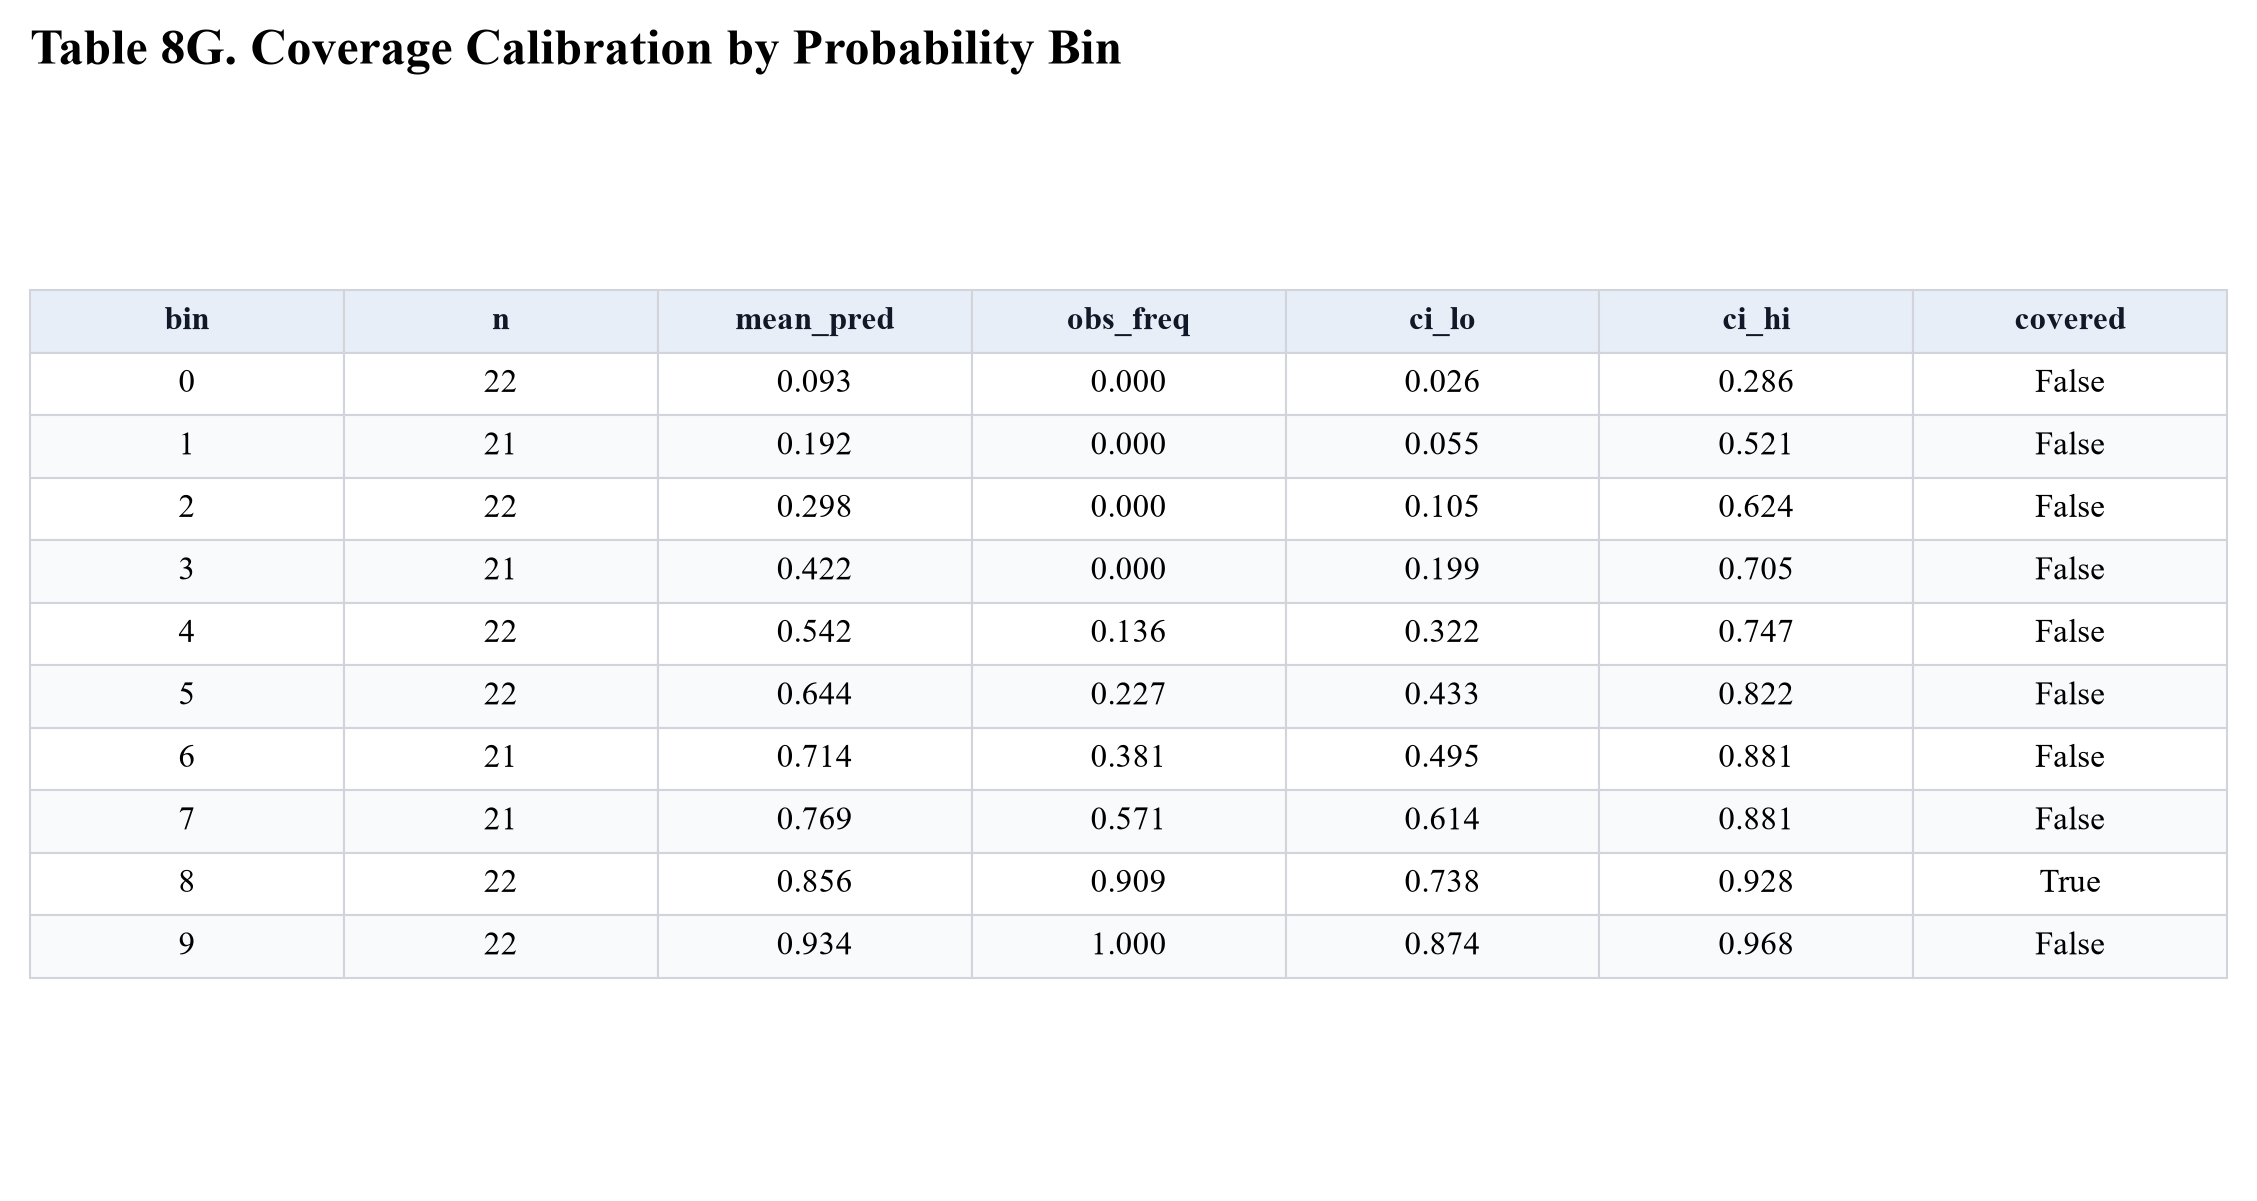

bin-level coverage = 0.10 (nominal 0.95)
  saved output_refactored/diagnostics\Fig8G_coverage_calibration.png and output_refactored/diagnostics\Fig8G_coverage_calibration.pdf


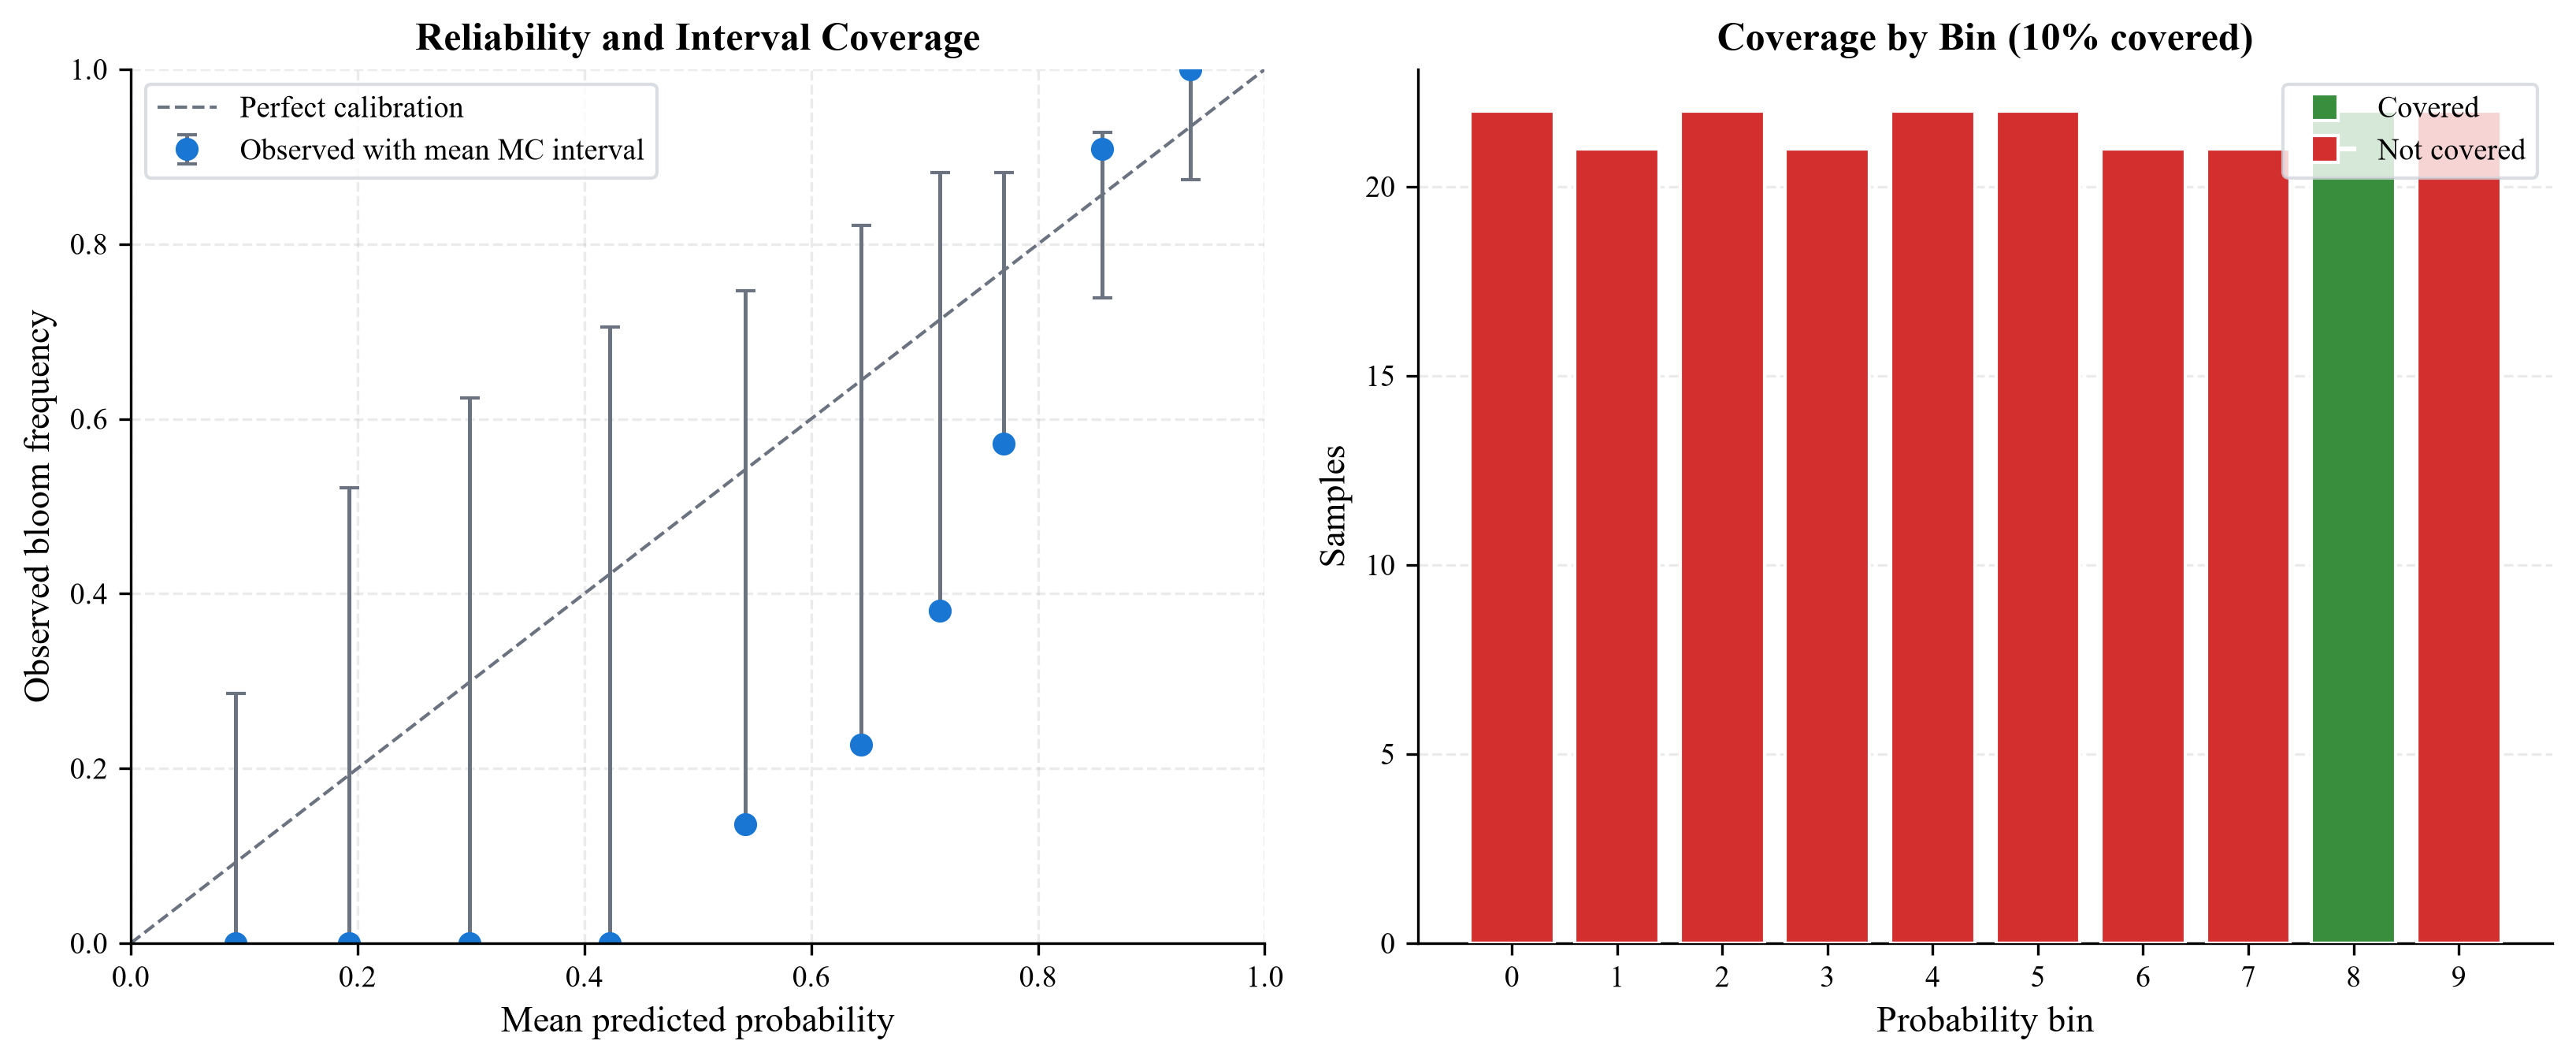

In [8]:
bins = np.quantile(y_mean, np.linspace(0, 1, 11))
bins = np.unique(bins)
if len(bins) < 2:
    cov = pd.DataFrame(columns=['bin', 'n', 'mean_pred', 'obs_freq', 'ci_lo', 'ci_hi', 'covered'])
else:
    bin_idx = np.clip(np.searchsorted(bins, y_mean, side='right') - 1, 0, len(bins) - 2)
    rows = []
    for b in range(len(bins) - 1):
        m = bin_idx == b
        if m.sum() == 0:
            continue
        obs = y_actual[m].mean()
        lo, hi = ci_lo[m].mean(), ci_hi[m].mean()
        rows.append({
            'bin': b,
            'n': int(m.sum()),
            'mean_pred': y_mean[m].mean(),
            'obs_freq': obs,
            'ci_lo': lo,
            'ci_hi': hi,
            'covered': bool(lo <= obs <= hi),
        })
    cov = pd.DataFrame(rows)

save_table(cov, 'Table8_coverage_calibration.csv', 'Table 8G. Coverage Calibration by Probability Bin')

if len(cov) > 0:
    coverage_rate = cov['covered'].mean()
    print(f'bin-level coverage = {coverage_rate:.2f} (nominal 0.95)')
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    axes[0].plot([0, 1], [0, 1], color=COLORS['gray'], linestyle='--', linewidth=1, label='Perfect calibration')
    yerr = np.vstack([np.maximum(cov['obs_freq'] - cov['ci_lo'], 0),
                      np.maximum(cov['ci_hi'] - cov['obs_freq'], 0)])
    axes[0].errorbar(cov['mean_pred'], cov['obs_freq'], yerr=yerr,
                     fmt='o', color=COLORS['blue'], ecolor=COLORS['gray'],
                     elinewidth=1.2, capsize=3, label='Observed with mean MC interval')
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel('Mean predicted probability')
    axes[0].set_ylabel('Observed bloom frequency')
    axes[0].set_title('Reliability and Interval Coverage', fontweight='bold')
    axes[0].legend(frameon=True, edgecolor='#D1D5DB')
    axes[0].grid(alpha=0.25, linestyle='--')
    bar_colors = np.where(cov['covered'], COLORS['green'], COLORS['red'])
    axes[1].bar(cov['bin'].astype(str), cov['n'], color=bar_colors, edgecolor='white', zorder=3)
    axes[1].set_xlabel('Probability bin')
    axes[1].set_ylabel('Samples')
    axes[1].set_title(f'Coverage by Bin ({coverage_rate:.0%} covered)', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.25, linestyle='--', zorder=0)
    legend_handles = [plt.Line2D([0], [0], marker='s', color='w', label='Covered', markerfacecolor=COLORS['green'], markersize=8),
                      plt.Line2D([0], [0], marker='s', color='w', label='Not covered', markerfacecolor=COLORS['red'], markersize=8)]
    axes[1].legend(handles=legend_handles, frameon=True, edgecolor='#D1D5DB')
    plt.tight_layout()
    savefig(fig, 'Fig8G_coverage_calibration')
    plt.show()
else:
    print('Coverage calibration skipped: no probability bins available.')


## Section H — Uncertainty cross-validation (Analysis 9)

Spearman correlations with bootstrap CIs among `y_std`, the (redundant) `entropy`, and
baseline disagreement. The `y_std` vs disagreement correlation is the meaningful one.

  saved table output_refactored/diagnostics\Table8_uncertainty_correlations.csv


,pair,rho,ci_lo,ci_hi
0,MC spread vs Entropy,0.647507,0.553646,0.731676
1,MC spread vs Baseline disagreement,-0.599735,-0.681500,-0.510554
2,Entropy vs Baseline disagreement,-0.356375,-0.468987,-0.237306


  saved output_refactored/diagnostics\Table8_uncertainty_correlations.png and output_refactored/diagnostics\Table8_uncertainty_correlations.pdf


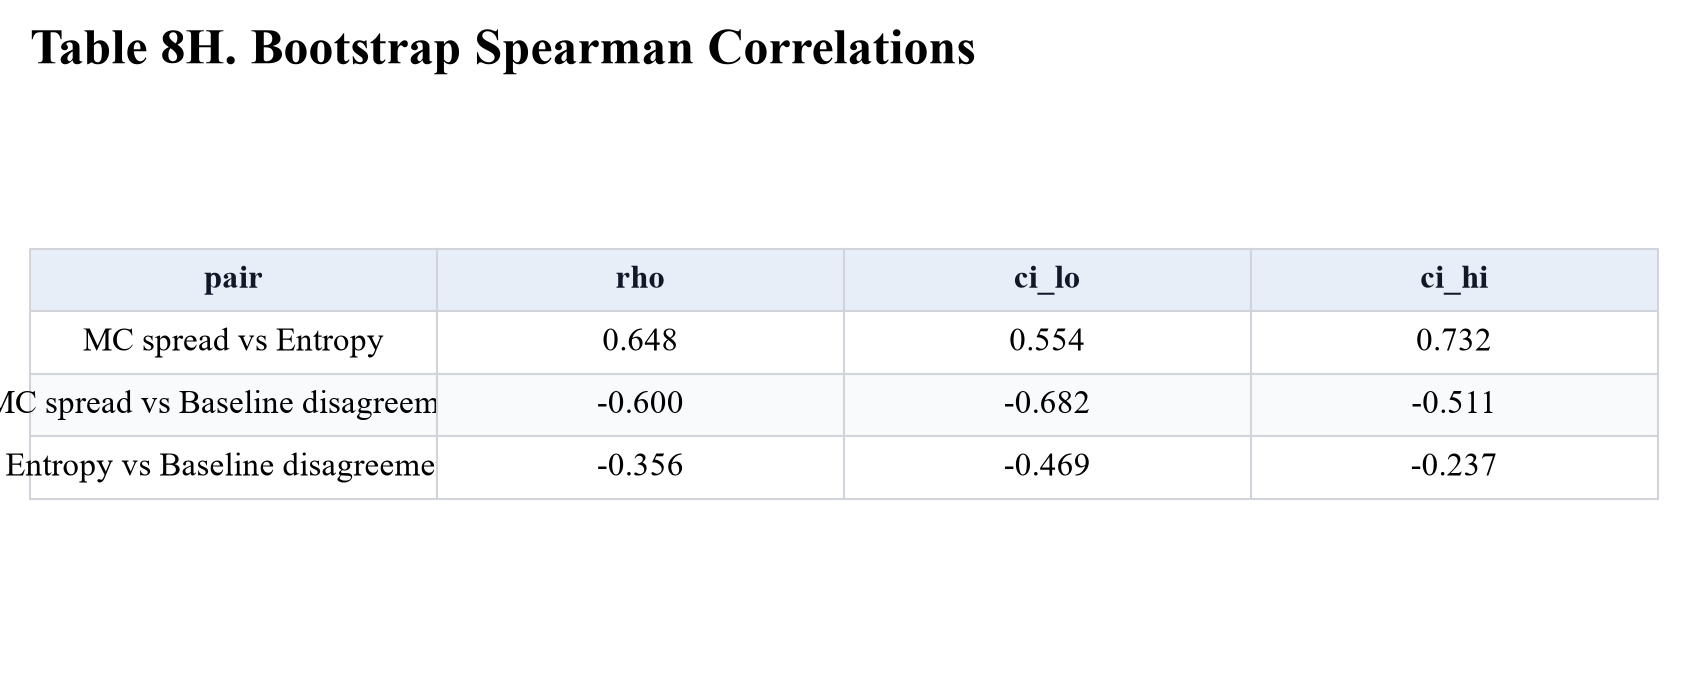

  saved output_refactored/diagnostics\Fig8H_uncertainty_correlations.png and output_refactored/diagnostics\Fig8H_uncertainty_correlations.pdf


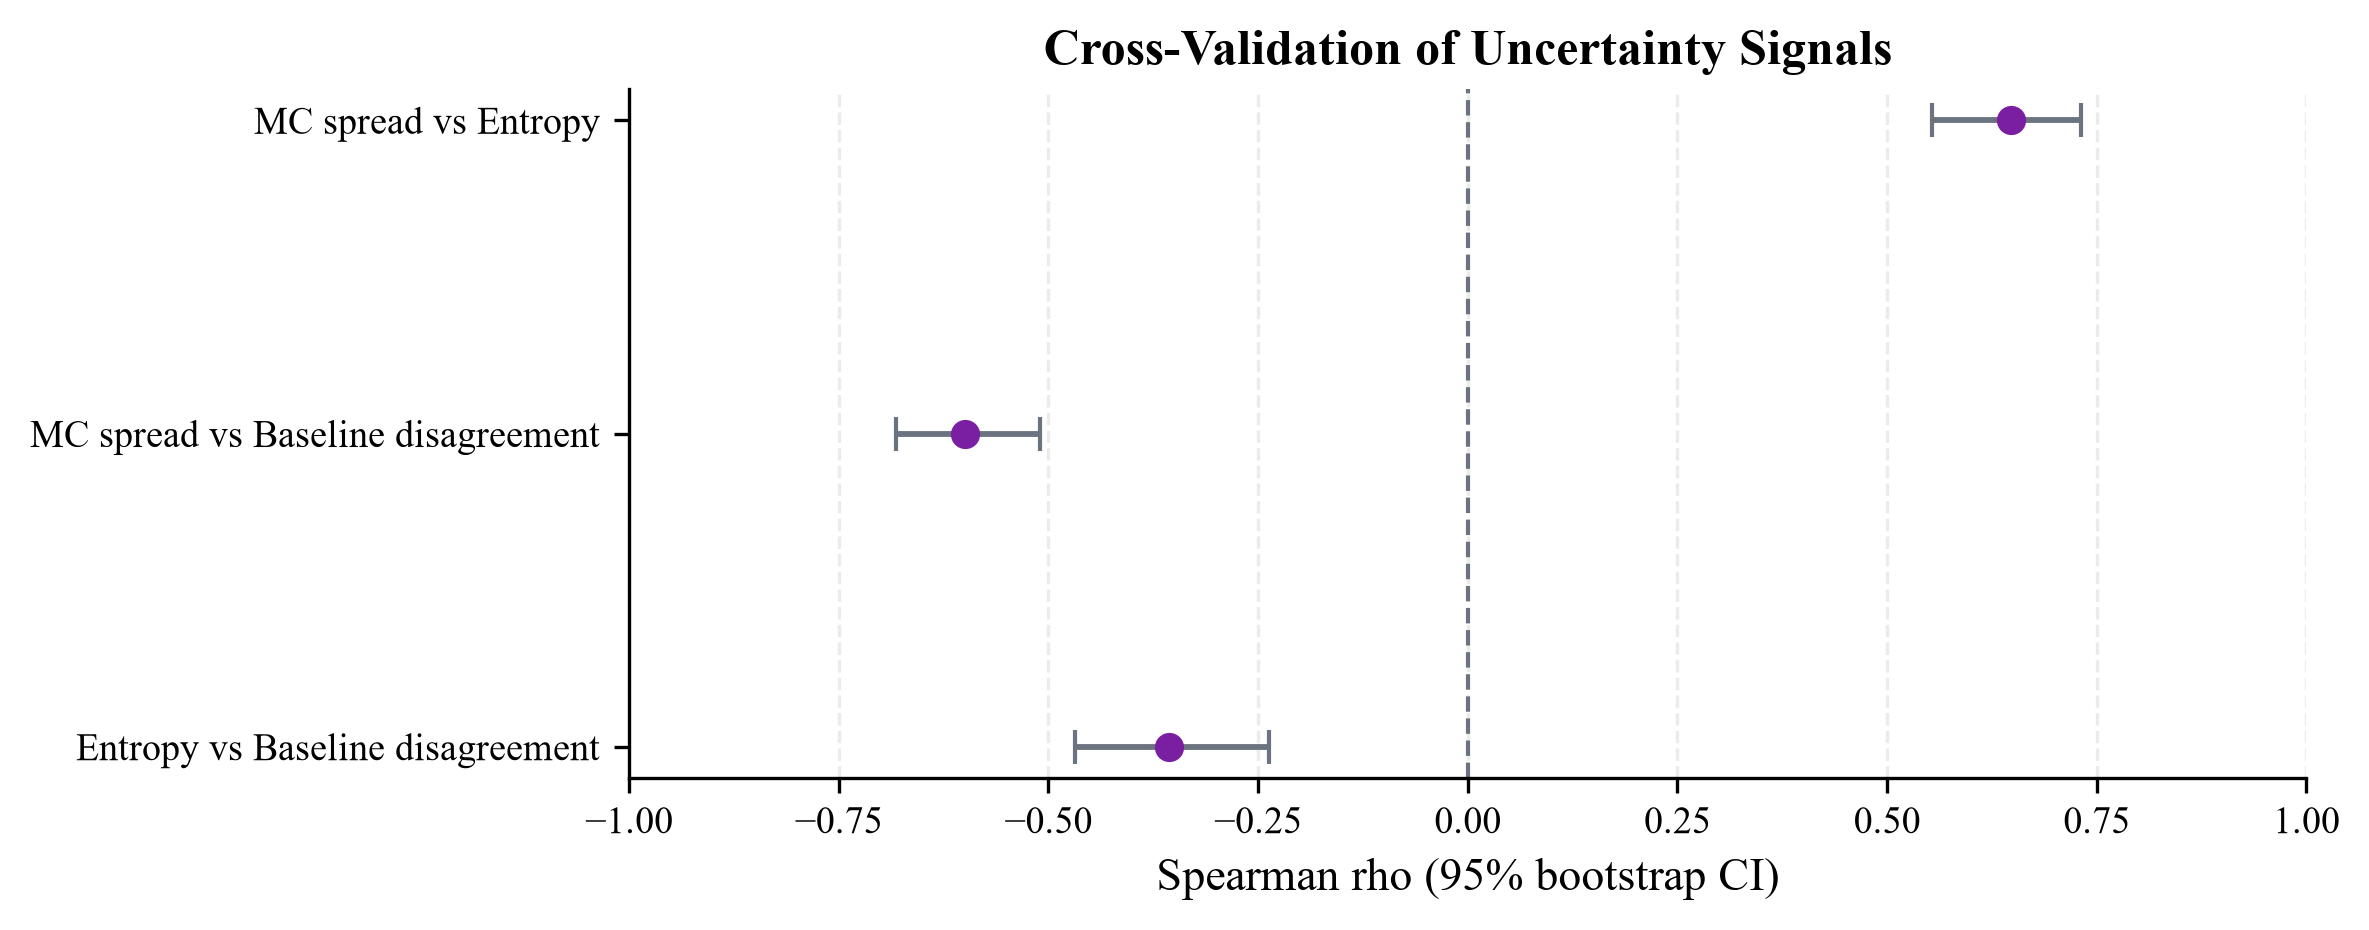

  saved table output_refactored/diagnostics\Table8_diagnostic_artifact_manifest.csv


,artifact_type,path
0,table,output_refactored\diagnostics\Table8_coverage_...
1,table,output_refactored\diagnostics\Table8_diagnosti...
2,table,output_refactored\diagnostics\Table8_stratifie...
3,table,output_refactored\diagnostics\Table8_tiered_sy...
4,table,output_refactored\diagnostics\Table8_triage_qu...
5,table,output_refactored\diagnostics\Table8_uncertain...
6,table,output_refactored\diagnostics\Table8_uncertain...
7,table,output_refactored\diagnostics\Table8_uncertain...
8,table,output_refactored\diagnostics\Table8_variance_...
9,table,output_refactored\diagnostics\Table8_variance_...


'output_refactored/diagnostics\\Table8_diagnostic_artifact_manifest.csv'

In [9]:
def boot_spearman(a, b, n=2000, seed=SEED):
    a = np.asarray(a)
    b = np.asarray(b)
    # Defensive length alignment: if the two signals were generated at
    # different sequence lengths, correlate over their common trailing window.
    if len(a) != len(b):
        m = min(len(a), len(b))
        a = a[-m:]
        b = b[-m:]
    rng = np.random.RandomState(seed)
    n_obs = len(a)
    vals = []
    for _ in range(n):
        idx = rng.choice(n_obs, n_obs, replace=True)
        stat = spearmanr(a[idx], b[idx]).statistic
        if np.isfinite(stat):
            vals.append(stat)
    if not vals:
        return np.nan, np.nan, np.nan
    return float(np.mean(vals)), float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

pairs = [('MC spread', 'Entropy', y_std, entropy)]
if len(have) >= 2 and agree_count is not None:
    # agree_count / disagreement live on the baseline-aligned axis (length Nb),
    # so pair them with the baseline-aligned spread/entropy views.
    disagreement = (len(have) - np.maximum(agree_count, len(have) - agree_count)).astype(float)
    pairs += [('MC spread', 'Baseline disagreement', yb_std, disagreement),
              ('Entropy', 'Baseline disagreement', yb_entropy, disagreement)]
rows = []
for an, bn, a, b in pairs:
    r, lo, hi = boot_spearman(a, b)
    rows.append({'pair': f'{an} vs {bn}', 'rho': r, 'ci_lo': lo, 'ci_hi': hi})
corr = pd.DataFrame(rows)
save_table(corr, 'Table8_uncertainty_correlations.csv',
           'Table 8H. Bootstrap Spearman Correlations')

if len(corr) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3.2, 0.55 * len(corr) + 1.2)))
    y = np.arange(len(corr))
    rho = corr['rho'].astype(float).values
    lo = corr['ci_lo'].astype(float).values
    hi = corr['ci_hi'].astype(float).values
    xerr = np.vstack([rho - lo, hi - rho])
    ax.axvline(0, color=COLORS['gray'], linestyle='--', linewidth=1)
    ax.errorbar(rho, y, xerr=xerr, fmt='o', color=COLORS['purple'],
                ecolor=COLORS['gray'], elinewidth=1.4, capsize=4)
    ax.set_yticks(y)
    ax.set_yticklabels(corr['pair'])
    ax.set_xlabel('Spearman rho (95% bootstrap CI)')
    ax.set_title('Cross-Validation of Uncertainty Signals', fontweight='bold')
    ax.set_xlim(-1, 1)
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    ax.invert_yaxis()
    plt.tight_layout()
    savefig(fig, 'Fig8H_uncertainty_correlations')
    plt.show()

manifest_rows = []
for path in sorted(Path(DIAG_DIR).glob('Table8_*.csv')):
    manifest_rows.append({'artifact_type': 'table', 'path': str(path)})
for path in sorted(Path(DIAG_DIR).glob('Fig8*.png')):
    manifest_rows.append({'artifact_type': 'figure_png', 'path': str(path)})
manifest = pd.DataFrame(manifest_rows)
save_table(manifest, 'Table8_diagnostic_artifact_manifest.csv',
           'Table 8I. Diagnostic Artifact Manifest', render=False, compat_copy=False)
